# StreamView Analytics — Evaluación Parcial N°1
## Visualización de Datos (ADY1104)

**Caso de estudio:** StreamView Analytics — plataforma ficticia de streaming digital

**Integrantes:** [Matias Arauz] · [Michelangelo Bandelli] · [Sebastian Gonzalez Pino] · [Hernan Lippke]

**Docente:** [Pablo Espinoza]

**Fecha:** [19-09-2026]

**Período de análisis:** 01-01-2025 al 31-12-2025

---

## Tabla de contenidos

[Definición del problema de negocio](#1)

[Audiencia objetivo y propósito comunicacional](#2)

[Fuentes de datos y metodología](#3)

Análisis exploratorio y hallazgos por integrante
   - Retención y cancelación de clientes — ✅ *Sebas* — Responsable: **Sebastian Gonzalez Pino**
   - Reproducciones, minutos vistos, % completado y abandono — * — Responsable: **[Hernan]**
   - Preferencias de contenido — ✅ *Michel* — Responsable: **[Michelangelo]**
   - Experiencia técnica por dispositivo — ✅ *Matias* — Responsable: **Matias Arauz**
   - Relación entre consumo, interacciones y calificaciones — * — Responsable: **[Hernan]**

Dashboard ejecutivo y KPIs — 🔲 *Pendiente (grupal)*

Data Storytelling / narrativa visual — 🔲 *Pendiente (grupal)*

Conclusiones y recomendaciones — 🔲 *Pendiente

> **¿Qué queremos analizar? → ¿Por qué elegimos este gráfico? → ¿Qué hallazgo encontramos? → ¿Qué significa para la organización? → ¿Qué decisión o recomendación podemos proponer?**


### Definición del problema de negocio — 🔲 *Pendiente revision (grupal)*

**Preguntas guía para completar en equipo:**
- ¿Qué decisión de negocio queremos apoyar? (retención, upsell de planes, inversión en catálogo, mejora técnica, etc.)
- ¿Por qué es un problema relevante hoy para StreamView Analytics?
- ¿Qué pasaría si no se aborda?

> StreamView Analytics necesita entender qué combinación de contenido, dispositivo y experiencia de uso mantiene a un usuario reproduciendo, interactuando y suscrito, para dirigir mejor sus decisiones de catálogo, producto y retención.


### Audiencia objetivo y propósito comunicacional — 🔲 *Pendiente revision (grupal)*

**Preguntas guía para completar en equipo:**
- ¿Quién va a ver el dashboard/reporte? (ej. Gerencia de Producto, equipo de Retención, Marketing, Dirección General)
- ¿Qué nivel de detalle técnico maneja esa audiencia?
- ¿Qué decisión concreta tomará esa audiencia con lo que le mostremos?
- ¿Qué tono/formato es el adecuado (ejecutivo y de alto nivel vs. analítico y detallado)?

*Sugerencia:* dado que las 5 líneas de análisis del equipo combinan negocio (retención), producto (contenido, consumo) y tecnología (dispositivos), una audiencia natural es un **comité de Producto y Retención**, con un propósito **informativo + persuasivo**: mostrar dónde se pierde/gana engagement y qué acción tomar.

### Fuentes de datos y metodología

Trabajamos con las 7 tablas del dataset StreamView Analytics descritas en el `README.txt` y su diccionario de datos. Las claves de relación son:

- `usuarios.usuario_id` → `suscripciones`, `dispositivos`, `reproducciones`, `calificaciones`, `interacciones`
- `contenidos.contenido_id` → `reproducciones`, `calificaciones`, `interacciones`
- `dispositivos.dispositivo_id` → `reproducciones.dispositivo_id`

### Librerías y carga de datos

In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

### Configuración visual

In [2]:
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Paleta de equipo: gris neutro para "el resto" + color de acento para destacar
# el hallazgo relevante en cada gráfico (principio de jerarquía visual / preatención)
COLOR_NEUTRO = "#B0B7C3"
COLOR_ACENTO = "#E4572E"   # naranja: para alertar (ej. peor desempeño)
COLOR_ACENTO_POS = "#2E86AB"  # azul: para destacar en positivo
COLOR_LINEA = "#264653"

In [3]:
from pathlib import Path

# Carpeta de datos: ../data al trabajar desde el repositorio; carpeta actual en Colab
DATA_DIR = Path('../data') if Path('../data').exists() else Path('.')

contenidos = pd.read_csv(DATA_DIR / 'contenidos.csv')
diccionario_datos = pd.read_csv(DATA_DIR / 'diccionario_datos.csv')
dispositivos = pd.read_csv(DATA_DIR / 'dispositivos.csv')
reproducciones = pd.read_csv(DATA_DIR / 'reproducciones.csv')
suscripciones = pd.read_csv(DATA_DIR / 'suscripciones.csv')
usuarios = pd.read_csv(DATA_DIR / 'usuarios.csv')
interacciones = pd.read_csv(DATA_DIR / 'interacciones.csv')
calificaciones = pd.read_csv(DATA_DIR / 'calificaciones.csv')

### Descripción general de las tablas

In [4]:
tablas = {
    'usuarios': usuarios, 'contenidos': contenidos, 'suscripciones': suscripciones,
    'dispositivos': dispositivos, 'reproducciones': reproducciones,
    'calificaciones': calificaciones, 'interacciones': interacciones,
}

for nombre, df in tablas.items():
    print(f"{nombre:15s} -> {df.shape[0]:>6,} filas | {df.shape[1]} columnas")

usuarios        ->  1,500 filas | 8 columnas
contenidos      ->    420 filas | 14 columnas
suscripciones   ->  1,500 filas | 9 columnas
dispositivos    ->  2,492 filas | 6 columnas
reproducciones  -> 25,000 filas | 11 columnas
calificaciones  ->  3,119 filas | 7 columnas
interacciones   ->  7,438 filas | 7 columnas


### Diccionario de datos completo (referencia para todo el equipo):

In [5]:
diccionario_datos

,Tabla,Campo,Tipo,Descripción,Clave/Relación
0,usuarios,usuario_id,Texto,Identificador único del usuario.,PK
1,usuarios,fecha_registro,Fecha,Fecha de alta del usuario en la plataforma.,NaN
2,usuarios,pais,Texto,País de residencia.,NaN
3,usuarios,ciudad,Texto,Ciudad de residencia.,NaN
4,usuarios,edad,Entero,Edad del usuario.,NaN
...,...,...,...,...,...
57,interacciones,contenido_id,Texto,Contenido asociado.,FK -> contenidos.contenido_id
58,interacciones,fecha_hora,FechaHora,Fecha y hora del evento.,NaN
59,interacciones,tipo_interaccion,Texto,Acción realizada.,NaN
60,interacciones,canal,Texto,App o Web.,NaN


In [6]:
archivos = sorted(DATA_DIR.glob('*.csv'))
for archivo in archivos:
    df = pd.read_csv(archivo)
    print(f' Dataframe: {archivo.name} '.center(60, "="))
    df.info()
    display(df.head())
    display(df.describe())

============== Dataframe: calificaciones.csv ===============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3119 entries, 0 to 3118
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   calificacion_id       3119 non-null   object
 1   usuario_id            3119 non-null   object
 2   contenido_id          3119 non-null   object
 3   fecha_calificacion    3119 non-null   object
 4   puntuacion_1_5        3119 non-null   int64 
 5   recomendaria          3119 non-null   object
 6   categoria_comentario  3119 non-null   object
dtypes: int64(1), object(6)
memory usage: 170.7+ KB


,calificacion_id,usuario_id,contenido_id,fecha_calificacion,puntuacion_1_5,recomendaria,categoria_comentario
0,K00001,U00975,C0363,2025-08-22 08:20:32,4,Sí,Contenido
1,K00002,U00975,C0135,2025-10-26 13:24:35,5,Sí,Historia
2,K00003,U00975,C0324,2025-04-22 20:21:42,4,Sí,Contenido
3,K00004,U00975,C0299,2025-06-07 00:40:30,4,Sí,Experiencia general
4,K00005,U00234,C0008,2025-12-23 20:16:42,4,Sí,Actuación


,puntuacion_1_5
count,3119.000000
mean,3.963450
std,0.539591
min,2.000000
25%,4.000000
50%,4.000000
75%,4.000000
max,5.000000


================ Dataframe: contenidos.csv =================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   contenido_id         420 non-null    object
 1   titulo               420 non-null    object
 2   tipo_contenido       420 non-null    object
 3   genero_principal     420 non-null    object
 4   subgenero            420 non-null    object
 5   clasificacion_edad   420 non-null    object
 6   anio_estreno         420 non-null    int64 
 7   duracion_min         420 non-null    int64 
 8   temporadas           420 non-null    int64 
 9   episodios            420 non-null    int64 
 10  idioma_original      420 non-null    object
 11  pais_origen          420 non-null    object
 12  exclusivo            420 non-null    object
 13  fecha_alta_catalogo  420 non-null    object
dtypes: int64(4), object(10)
memory usage: 46.1+ K

,contenido_id,titulo,tipo_contenido,genero_principal,subgenero,clasificacion_edad,anio_estreno,duracion_min,temporadas,episodios,idioma_original,pais_origen,exclusivo,fecha_alta_catalogo
0,C0001,Marea Alto 1,Serie,Comedia,Romántica,16+,2012,49,1,9,Inglés,Estados Unidos,No,2023-08-19
1,C0002,Tiempo Azul 2,Película,Documental,Sociedad,16+,2001,131,0,1,Español,España,No,2025-07-21
2,C0003,Eco Global 3,Película,Acción,Supervivencia,18+,2005,123,0,1,Inglés,Estados Unidos,Sí,2025-05-09
3,C0004,Destino Rojo 4,Película,Aventura,Exploración,13+,1998,98,0,1,Inglés,España,No,2025-04-08
4,C0005,Eco Norte 5,Documental,Drama,Histórico,13+,2000,73,0,1,Español,España,No,2023-11-24


...

,suscripcion_id,usuario_id,plan,fecha_inicio,fecha_fin,estado,precio_mensual_usd,renovacion_automatica,motivo_cancelacion
0,S00001,U00001,Premium,2024-02-06,NaN,Activa,13.99,Sí,NaN
1,S00002,U00002,Básico,2025-05-13,NaN,Activa,6.99,Sí,NaN
2,S00003,U00003,Básico,2023-03-17,2025-12-20,Cancelada,6.99,No,Precio
3,S00004,U00004,Estándar,2023-01-25,NaN,Activa,9.99,Sí,NaN
4,S00005,U00005,Estándar,2025-03-16,NaN,Activa,9.99,Sí,NaN


,precio_mensual_usd
count,1500.000000
mean,9.658667
std,2.517759
min,6.990000
25%,6.990000
50%,9.990000
75%,9.990000
max,13.990000


================= Dataframe: usuarios.csv ==================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   usuario_id         1500 non-null   object
 1   fecha_registro     1500 non-null   object
 2   pais               1500 non-null   object
 3   ciudad             1500 non-null   object
 4   edad               1500 non-null   int64 
 5   segmento_edad      1500 non-null   object
 6   genero             1500 non-null   object
 7   canal_adquisicion  1500 non-null   object
dtypes: int64(1), object(7)
memory usage: 93.9+ KB


,usuario_id,fecha_registro,pais,ciudad,edad,segmento_edad,genero,canal_adquisicion
0,U00001,2024-02-06,Chile,Concepción,33,25-34,Prefiere no indicar,Orgánico
1,U00002,2025-05-13,Chile,Valparaíso,63,55+,Femenino,Redes sociales
2,U00003,2023-03-17,México,Ciudad de México,32,25-34,Femenino,Referido
3,U00004,2023-01-25,España,Madrid,47,45-54,Femenino,Orgánico
4,U00005,2025-03-16,Chile,La Serena,41,35-44,Femenino,Orgánico


,edad
count,1500.000000
mean,34.393333
std,11.118320
min,18.000000
25%,26.000000
50%,34.000000
75%,42.000000
max,68.000000


### Calidad de datos

Revisamos valores nulos en cada tabla. Es esperable que `suscripciones` tenga nulos en `fecha_fin` y `motivo_cancelacion`: según el README, quedan vacíos cuando la suscripción sigue activa (no es un error de calidad).

In [7]:
for nombre, df in tablas.items():
    nulos = df.isna().sum()
    nulos = nulos[nulos > 0]
    if len(nulos):
        print(f"--- {nombre} ---")
        print(nulos.to_string())
        print()
    else:
        print(f"--- {nombre}: sin valores nulos ---\n")

--- usuarios: sin valores nulos ---

--- contenidos: sin valores nulos ---

--- suscripciones ---
fecha_fin             1085
motivo_cancelacion    1085

--- dispositivos: sin valores nulos ---

--- reproducciones: sin valores nulos ---

--- calificaciones: sin valores nulos ---

--- interacciones: sin valores nulos ---



### Duplicados e integridad de llaves (chequeo rápido, base para todo el equipo)

In [8]:
for nombre, df, pk in [
    ('usuarios', usuarios, 'usuario_id'),
    ('contenidos', contenidos, 'contenido_id'),
    ('suscripciones', suscripciones, 'suscripcion_id'),
    ('dispositivos', dispositivos, 'dispositivo_id'),
    ('reproducciones', reproducciones, 'reproduccion_id'),
    ('calificaciones', calificaciones, 'calificacion_id'),
    ('interacciones', interacciones, 'interaccion_id'),
]:
    dup = df[pk].duplicated().sum()
    print(f"{nombre:15s} -> llave primaria '{pk}': {dup} duplicados")

usuarios        -> llave primaria 'usuario_id': 0 duplicados
contenidos      -> llave primaria 'contenido_id': 0 duplicados
suscripciones   -> llave primaria 'suscripcion_id': 0 duplicados
dispositivos    -> llave primaria 'dispositivo_id': 0 duplicados
reproducciones  -> llave primaria 'reproduccion_id': 0 duplicados
calificaciones  -> llave primaria 'calificacion_id': 0 duplicados
interacciones   -> llave primaria 'interaccion_id': 0 duplicados


# Análisis exploratorio y hallazgos a realizar por integrante

## Retención y cancelación de clientes — ✅ *Sebastian Gonzalez Pino*

**Responsable:** Sebastian Gonzalez Pino

**Pregunta del README:** *Retención y cancelación de clientes por plan, país, segmento y canal.*
**Tablas principales:** `usuarios`, `suscripciones`

**¿Qué queremos analizar?**
Qué tan bien retiene StreamView a sus suscriptores y dónde se concentra la fuga: por plan, país, segmento de edad y canal de adquisición, y qué motivos declaran quienes cancelan.

**¿Por qué este gráfico?** Barras 100% apiladas por dimensión: la forma más directa de comparar la *proporción* de activas y canceladas entre categorías de tamaño muy distinto (p. ej. Chile con 470 usuarios vs. Ecuador con 67), sin que el tamaño de cada grupo distorsione la lectura visual.

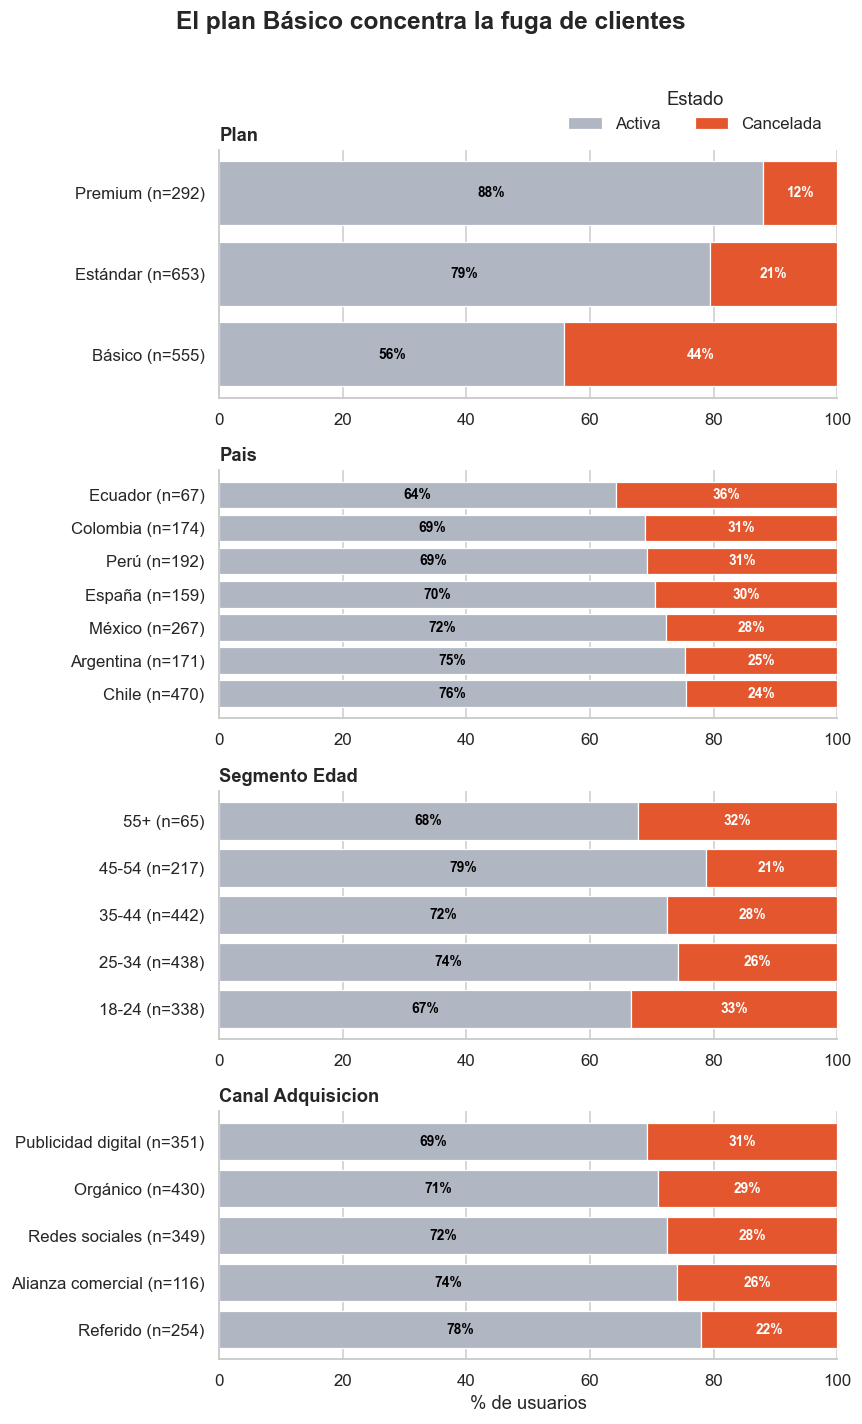

In [9]:
# Suscripciones: tasa de cancelación por dimensión (100% apilado, un panel por dimensión)
df_merged = usuarios.merge(suscripciones, on='usuario_id', how='left')
orden_plan = ['Básico', 'Estándar', 'Premium']
dimensiones = ['plan', 'pais', 'segmento_edad', 'canal_adquisicion']
n = len(dimensiones)

fig, axes = plt.subplots(n, 1, figsize=(8, 3.2 * n))

for i, col in enumerate(dimensiones):
    resumen = (df_merged.groupby(col)['estado']
               .value_counts(normalize=True).mul(100).unstack(fill_value=0))
    n_por_cat = df_merged.groupby(col)['estado'].count()

    if col == 'plan':
        orden = orden_plan
    elif col == 'segmento_edad':
        orden = sorted(df_merged[col].unique())
    else:
        orden = resumen['Cancelada'].sort_values(ascending=True).index.tolist()

    resumen = resumen.reindex(orden)
    n_por_cat = n_por_cat.reindex(orden)
    etiquetas = [f'{cat} (n={n_por_cat[cat]})' for cat in orden]

    ax = axes[i]
    izquierda = [0] * len(orden)
    for estado, color in [('Activa', COLOR_NEUTRO), ('Cancelada', COLOR_ACENTO)]:
        valores = resumen[estado].values
        ax.barh(etiquetas, valores, left=izquierda, color=color,
                edgecolor='white', linewidth=0.8, label=estado)
        for j, v in enumerate(valores):
            if v > 4:
                ax.text(izquierda[j] + v / 2, j, f'{v:.0f}%', va='center', ha='center',
                        fontsize=9, fontweight='bold',
                        color='white' if estado == 'Cancelada' else 'black')
        izquierda = [a + b for a, b in zip(izquierda, valores)]

    ax.set_title(col.replace('_', ' ').title(), loc='left', fontweight='bold', fontsize=12)
    ax.set_xlim(0, 100)
    ax.set_xlabel('% de usuarios' if i == n - 1 else '')
    if i == 0:
        ax.legend(title='Estado', loc='upper right', bbox_to_anchor=(1, 1.3), ncol=2, frameon=False)

fig.suptitle('El plan Básico concentra la fuga de clientes', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Hallazgo:**

- **Plan**: Básico concentra la fuga (44,1% cancela, casi 1 de cada 2). Estándar cancela 20,7% y Premium solo 12,0% (88% retiene).

- **País**: tasas de cancelación entre 24,5% (Chile) y 35,8% (Ecuador). Ecuador tiene muestra chica (n=67). Argentina y Chile retienen mejor (~75% activa).

- **Segmento de edad**: 45-54 cancela menos (21,2%, 79% activa). Los extremos cancelan más: 18-24 (33,4%, 67% activa) y 55+ (32,3%, 68% activa) — patrón típico de menor compromiso en jóvenes y posible fricción de adopción en mayores. El segmento 55+ tiene muestra chica (n=65), igual que Ecuador.

- **Canal de adquisición**: Referido cancela menos (22,0%): llegan pre-calificados. Publicidad digital cancela más (30,8%).

**¿Qué significa para StreamView?** La fuga no es pareja entre segmentos: se concentra en el plan Básico, en los extremos etarios y en la adquisición por publicidad digital. Antes de invertir en retención masiva, conviene priorizar estos grupos.

#### Motivos de cancelación

**¿Qué queremos analizar?** Por qué cancelan los usuarios que se van, y si el motivo cambia según el plan.

**¿Por qué este gráfico?** Barras horizontales ordenadas por frecuencia: la forma más legible para comparar categorías nominales (motivos declarados) con etiquetas de texto.

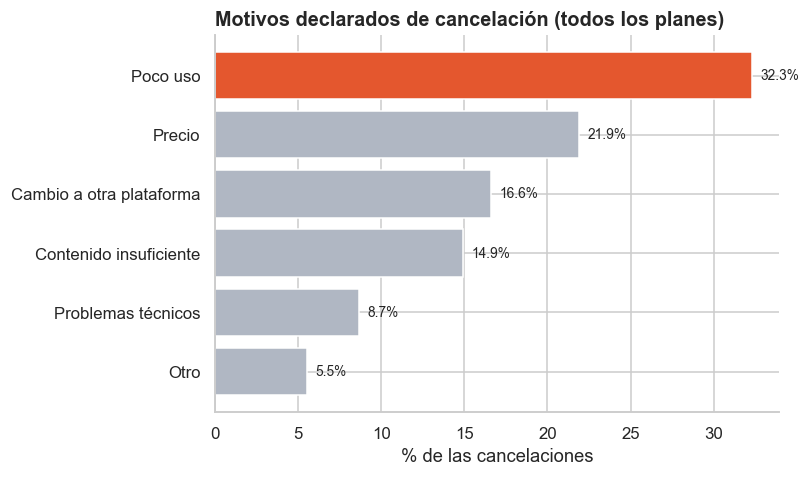

Motivo más declarado por plan:
    plan motivo_cancelacion  pct
  Básico           Poco uso 33.9
Estándar           Poco uso 29.6
 Premium           Poco uso 31.4


In [10]:
cancelados = usuarios.merge(suscripciones, on='usuario_id', how='left')
cancelados = cancelados[cancelados['estado'] == 'Cancelada']

motivos = (cancelados['motivo_cancelacion'].value_counts(normalize=True).mul(100)
           .rename_axis('motivo').reset_index(name='pct').sort_values('pct'))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
colores_motivo = [COLOR_ACENTO if m == motivos.iloc[-1]['motivo'] else COLOR_NEUTRO for m in motivos['motivo']]
ax.barh(motivos['motivo'], motivos['pct'], color=colores_motivo)
ax.set_title('Motivos declarados de cancelación (todos los planes)', loc='left', fontweight='bold')
ax.set_xlabel('% de las cancelaciones')
for i, v in enumerate(motivos['pct']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

top_por_plan = (cancelados.groupby('plan')['motivo_cancelacion']
                .value_counts(normalize=True).mul(100).round(1)
                .rename('pct').reset_index()
                .sort_values(['plan', 'pct'], ascending=[True, False])
                .groupby('plan').head(1))
print("Motivo más declarado por plan:")
print(top_por_plan.to_string(index=False))

**Hallazgo:** "Poco uso" es el motivo más declarado (32,3% de las cancelaciones), seguido de "Precio" (21,9%) y "Cambio a otra plataforma" (16,6%). El motivo varía por plan: en Básico predomina "Poco uso" (33,9%), en Estándar también "Poco uso" pero con "Precio" más cerca (25,2%), y en Premium "Poco uso" (31,4%) empata con "Contenido insuficiente" (22,9%).

**¿Qué significa para StreamView?** El motivo declarado no prueba causalidad: quienes cancelan también estuvieron activos menos meses en el año (5,8 meses en promedio vs. 10,2 de quien sigue activo), así que reproducen menos solo por tener menos tiempo en la plataforma. Normalizada por mes activo, la relación entre reproducciones y cancelación se invierte (mediana de 2,11 reproducciones/mes en cancelados vs. 1,67 en activos). No usamos "poco uso" como única causa de la fuga.

#### Cancelaciones por mes

**¿Por qué este gráfico?** Igual que en la evolución del consumo (línea 4.2), usamos barras por mes para ver si la fuga se concentra en algún momento del año, con el 2° semestre destacado.

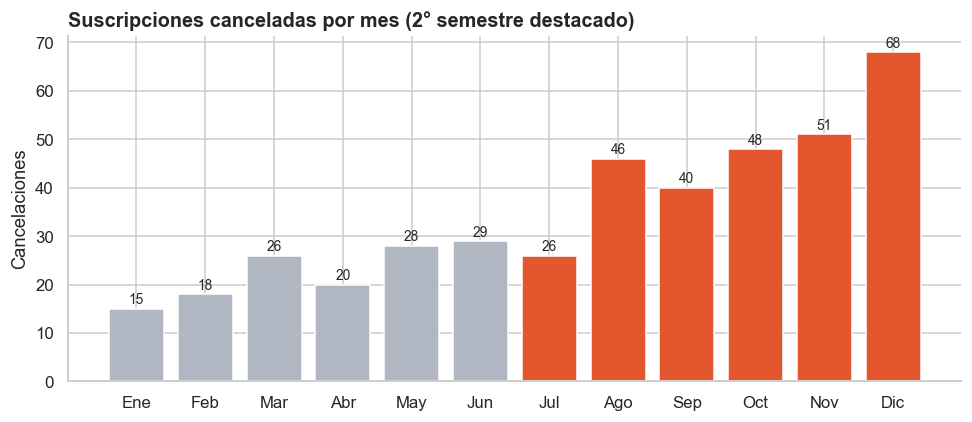

Cancelaciones en enero: 15 · en diciembre: 68
% de cancelaciones ocurridas en el 2° semestre: 67.2%


In [11]:
suscripciones['fecha_fin'] = pd.to_datetime(suscripciones['fecha_fin'])
cancel_mes = (suscripciones.dropna(subset=['fecha_fin'])
              .assign(mes=lambda d: d['fecha_fin'].dt.month)
              .groupby('mes').size().reindex(range(1, 13), fill_value=0))

meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
colores_mes = [COLOR_NEUTRO if m <= 6 else COLOR_ACENTO for m in cancel_mes.index]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(meses_nombres, cancel_mes.values, color=colores_mes)
ax.set_title('Suscripciones canceladas por mes (2° semestre destacado)', loc='left', fontweight='bold')
ax.set_ylabel('Cancelaciones')
for i, v in enumerate(cancel_mes.values):
    ax.text(i, v + 1, str(int(v)), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

pct_h2 = cancel_mes.loc[7:12].sum() / cancel_mes.sum() * 100
print(f"Cancelaciones en enero: {cancel_mes[1]} · en diciembre: {cancel_mes[12]}")
print(f"% de cancelaciones ocurridas en el 2° semestre: {pct_h2:.1f}%")

**Hallazgo:** las cancelaciones crecen fuerte durante el año: de 15 en enero a 68 en diciembre. El 67,2% de las cancelaciones del año ocurre en el segundo semestre.

**¿Qué significa para StreamView?** La fuga se acelera en el mismo período en que crece el consumo (línea 4.2): más actividad no se tradujo en más retención. Vale la pena revisar qué cambió operacionalmente en el 2° semestre (precios, catálogo, competencia) que coincide con el alza de cancelaciones.

**Nota metodológica — renovación automática:** el 100% de quienes tienen `renovacion_automatica = "No"` está cancelado, contra solo 7,9% de quienes tienen "Sí". Es probable que esto sea consecuencia de cancelar (el usuario desactiva la renovación al cancelar) y no una causa de la cancelación, así que no lo usamos como factor explicativo.

#### Recomendación

Priorizar campañas de reactivación y beneficios de upgrade para usuarios del plan Básico, especialmente antes del 2° semestre (cuando se acelera la fuga), midiendo su efecto en la tasa de cancelación mensual como KPI de seguimiento.

## Reproducciones, minutos vistos, % completado y abandono — *Hernan*

**Responsable:** [Hernan]

**Pregunta del README:** *Reproducciones, minutos vistos, porcentaje completado y abandono.*
**Tablas principales:** `reproducciones`, `contenidos`

**¿Qué queremos analizar?**
Cómo evoluciona el consumo (reproducciones y minutos vistos) durante 2025, qué tan completos son los visionados (`porcentaje_completado`) y qué factores —dispositivo, calidad de video, buffering, tipo de contenido— se asocian al abandono temprano (`abandono_temprano`, definido como <20% de avance).

#### Preparación de datos

In [12]:
reproducciones['fecha_hora_inicio'] = pd.to_datetime(reproducciones['fecha_hora_inicio'])
reproducciones['mes'] = reproducciones['fecha_hora_inicio'].dt.to_period('M').astype(str)

rep_full = reproducciones.merge(
    contenidos[['contenido_id', 'titulo', 'tipo_contenido', 'genero_principal']],
    on='contenido_id', how='left'
)

print(f"Reproducciones totales: {len(rep_full):,}")
print(f"Usuarios distintos que reprodujeron: {rep_full['usuario_id'].nunique():,}")
print(f"Contenidos distintos reproducidos: {rep_full['contenido_id'].nunique():,}")
print(f"Minutos totales vistos en el período: {rep_full['minutos_reproducidos'].sum():,.0f} min")
print(f"Tasa de abandono temprano global: {(rep_full['abandono_temprano']=='Sí').mean()*100:.2f}%")

Reproducciones totales: 25,000
Usuarios distintos que reprodujeron: 1,500
Contenidos distintos reproducidos: 420
Minutos totales vistos en el período: 1,423,491 min
Tasa de abandono temprano global: 0.40%


#### Evolución mensual de reproducciones y minutos vistos

**¿Por qué este gráfico?** Para ver evolución en el tiempo, la línea temporal es el tipo de gráfico más directo (posición en eje X = tiempo), y usamos dos paneles alineados en vez de un eje doble, para no distorsionar la comparación visual entre dos escalas distintas (buena práctica: evitar doble eje Y engañoso).

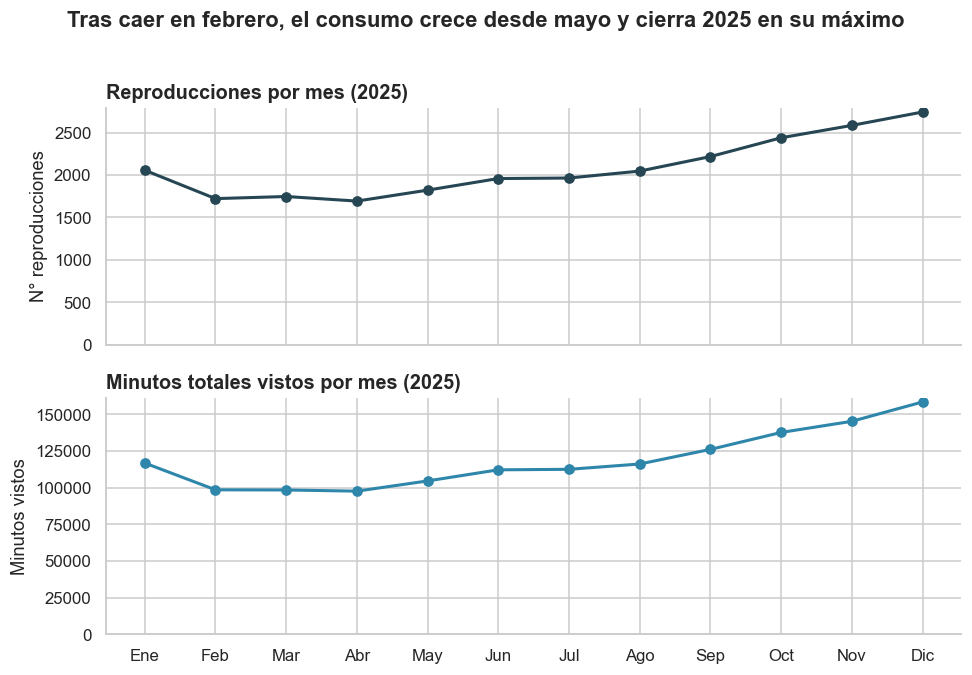

Diciembre vs. enero: +35.6%
Diciembre vs. abril (mínimo del año): +62.2%
2.º semestre vs. 1.er semestre: +26.7%


In [13]:
mensual = rep_full.groupby('mes').agg(
    n_reproducciones=('reproduccion_id', 'count'),
    minutos_totales=('minutos_reproducidos', 'sum')
).reset_index()
MESES = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
mensual['mes_nombre'] = [MESES[int(m[-2:]) - 1] for m in mensual['mes']]

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(mensual['mes_nombre'], mensual['n_reproducciones'], marker='o', color=COLOR_LINEA, linewidth=2)
axes[0].set_title('Reproducciones por mes (2025)', loc='left')
axes[0].set_ylabel('N° reproducciones')
axes[0].set_ylim(bottom=0)

axes[1].plot(mensual['mes_nombre'], mensual['minutos_totales'], marker='o', color=COLOR_ACENTO_POS, linewidth=2)
axes[1].set_title('Minutos totales vistos por mes (2025)', loc='left')
axes[1].set_ylabel('Minutos vistos')
axes[1].set_ylim(bottom=0)

fig.suptitle('Tras caer en febrero, el consumo crece desde mayo y cierra 2025 en su máximo', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

minutos = mensual['minutos_totales']
print(f"Diciembre vs. enero: {(minutos.iloc[-1] / minutos.iloc[0] - 1) * 100:+.1f}%")
print(f"Diciembre vs. abril (mínimo del año): {(minutos.iloc[-1] / minutos.min() - 1) * 100:+.1f}%")
print(f"2.º semestre vs. 1.er semestre: {(minutos.iloc[6:].sum() / minutos.iloc[:6].sum() - 1) * 100:+.1f}%")

**Hallazgo:** reproducciones y minutos se mueven en paralelo (r = 0,998). Enero parte alto (116.734 minutos), febrero cae 16% y el consumo se mantiene plano hasta abril, el mínimo del año (97.599). Desde mayo crece casi todos los meses (julio queda plano) y se acelera desde septiembre: diciembre cierra con 158.315 minutos, el máximo del año, +62% sobre abril y +36% sobre enero.

**¿Qué significa para StreamView?** El segundo semestre es claramente más fuerte (+27% de minutos que el primero). El alza viene más de la intensidad que de la base: los usuarios que reproducen en el mes suben 14% entre enero y diciembre, mientras las reproducciones suben 33%. Conviene cruzar esto con retención (4.1), porque más consumo no garantiza más suscriptores activos.

#### Distribución del porcentaje completado

**¿Por qué este gráfico?** Un histograma es la forma estándar de mostrar la forma de una distribución continua (asimetría, concentración), mejor que un promedio único que oculta la dispersión.

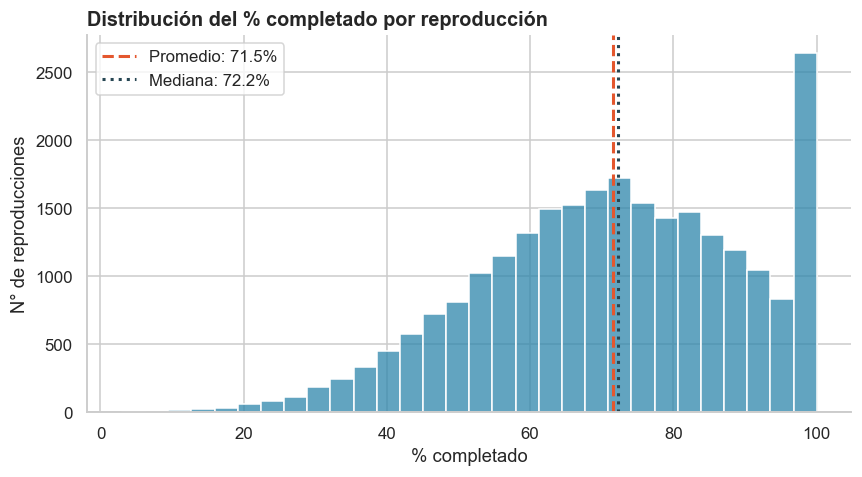

In [14]:
media_pct = rep_full['porcentaje_completado'].mean()
mediana_pct = rep_full['porcentaje_completado'].median()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(rep_full['porcentaje_completado'], bins=30, color=COLOR_ACENTO_POS, ax=ax)
ax.axvline(media_pct, color=COLOR_ACENTO, linestyle='--', linewidth=2, label=f'Promedio: {media_pct:.1f}%')
ax.axvline(mediana_pct, color=COLOR_LINEA, linestyle=':', linewidth=2, label=f'Mediana: {mediana_pct:.1f}%')
ax.set_title('Distribución del % completado por reproducción', loc='left', fontweight='bold')
ax.set_xlabel('% completado')
ax.set_ylabel('N° de reproducciones')
ax.legend()
plt.tight_layout()
plt.show()

**Hallazgo:** el % completado promedio es 71,5% y la mediana 72,2%. La mitad central de las reproducciones está entre 59% y 86% completado. La cola baja (menos de 20% de avance) es pequeña en volumen, 99 de 25.000 reproducciones (0,4%), pero es el "abandono duro" que analizamos a continuación.

**¿Qué significa para StreamView?** La mayoría de las reproducciones sí retienen a los usuarios más allá de la mitad del contenido; el problema de abandono, más que masivo, está concentrado en condiciones específicas (dispositivo, calidad), que revisamos en los siguientes gráficos.

#### Completado y abandono temprano según tipo de dispositivo

**¿Por qué este gráfico?** Barras horizontales ordenadas por valor son el tipo de gráfico más eficiente para comparar una métrica entre pocas categorías (5 tipos de dispositivo). Usamos color de acento sólo en la categoría con peor desempeño para dirigir la atención (jerarquía visual).

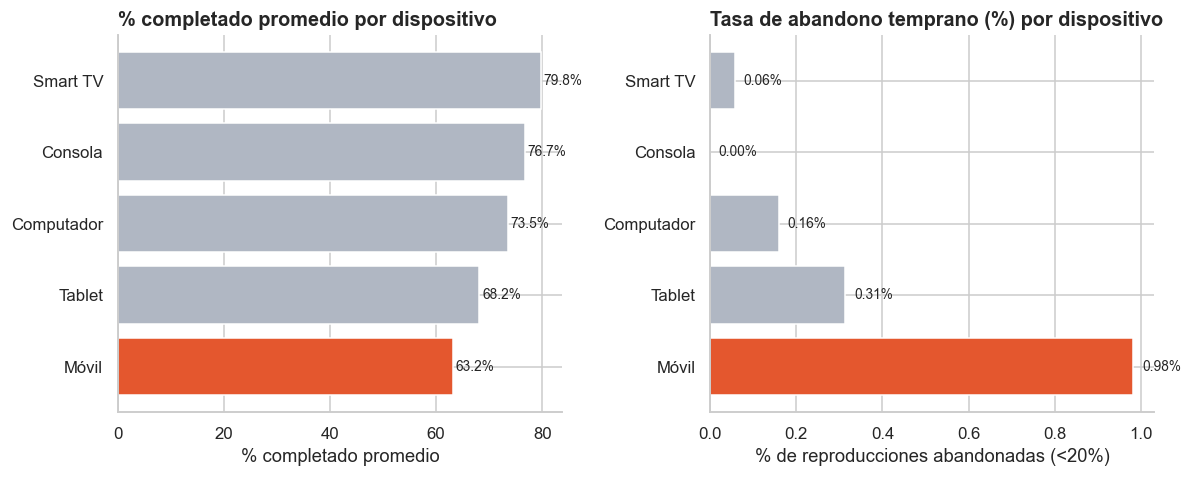

In [15]:
pct_disp = rep_full.groupby('tipo_dispositivo')['porcentaje_completado'].mean().sort_values()
aband_disp = rep_full.groupby('tipo_dispositivo')['abandono_temprano'].apply(lambda x: (x == 'Sí').mean() * 100).reindex(pct_disp.index)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

colores1 = [COLOR_ACENTO if d == pct_disp.idxmin() else COLOR_NEUTRO for d in pct_disp.index]
axes[0].barh(pct_disp.index, pct_disp.values, color=colores1)
axes[0].set_title('% completado promedio por dispositivo', loc='left', fontweight='bold')
axes[0].set_xlabel('% completado promedio')
for i, v in enumerate(pct_disp.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

colores2 = [COLOR_ACENTO if d == aband_disp.idxmax() else COLOR_NEUTRO for d in aband_disp.index]
axes[1].barh(aband_disp.index, aband_disp.values, color=colores2)
axes[1].set_title('Tasa de abandono temprano (%) por dispositivo', loc='left', fontweight='bold')
axes[1].set_xlabel('% de reproducciones abandonadas (<20%)')
for i, v in enumerate(aband_disp.values):
    axes[1].text(v + 0.02, i, f'{v:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Hallazgo:** Móvil es el dispositivo más usado (30,6% de las reproducciones) y el de peor experiencia: tiene el menor % completado (63,2% contra 79,8% en Smart TV) y la mayor tasa de abandono temprano (0,98%). Con menos de un tercio de las reproducciones, concentra 75 de los 99 abandonos del año (76%). Móvil y Tablet duplican el buffering promedio del resto (≈11,5 s contra ≈5,8 s).

**¿Qué significa para StreamView?** El problema de abandono no es general: se concentra en las pantallas móviles, justamente donde más se consume. Mejorar la reproducción en móvil (precarga, calidad adaptativa, recuperación ante cortes) ataca el 76% del abandono con un solo frente de trabajo.

#### Calidad de video, buffering y % completado

**¿Por qué este gráfico?** Para una relación entre dos variables continuas (buffering y % completado) usamos un gráfico de dispersión con línea de tendencia, que permite ver tanto la forma de la relación como su fuerza aproximada. La calidad de video se resume en una tabla porque son solo 4 categorías con 3 métricas cada una.

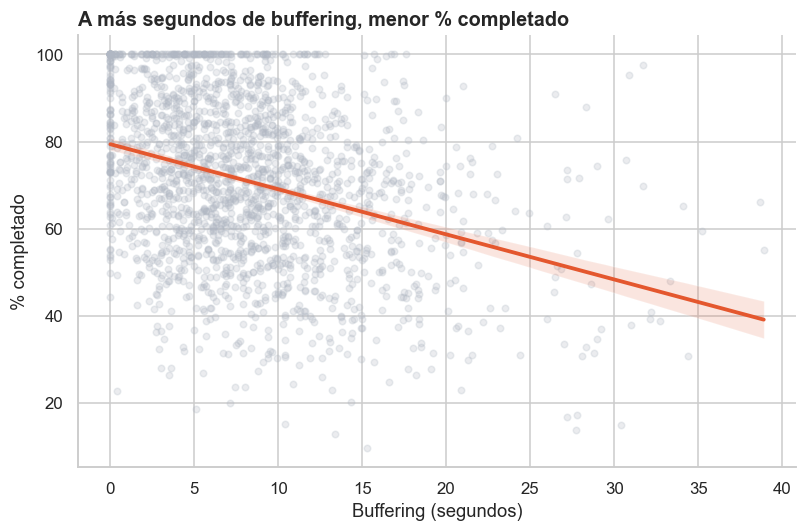

Correlación buffering vs. % completado: -0.31

% completado promedio y buffering promedio por calidad de video:


,pct_completado_prom,buffering_prom,tasa_abandono
calidad_video,,,
SD,71.25,8.13,0.51
HD,71.21,8.26,0.37
Full HD,71.55,7.99,0.42
4K,72.38,9.04,0.32


In [16]:
muestra = rep_full.sample(2000, random_state=42)

fig, ax = plt.subplots(figsize=(7.5, 5))
sns.regplot(
    data=muestra, x='buffering_segundos', y='porcentaje_completado',
    scatter_kws={'alpha': 0.25, 'color': COLOR_NEUTRO, 's': 18},
    line_kws={'color': COLOR_ACENTO, 'linewidth': 2.5}, ax=ax
)
ax.set_title('A más segundos de buffering, menor % completado', loc='left', fontweight='bold')
ax.set_xlabel('Buffering (segundos)')
ax.set_ylabel('% completado')
plt.tight_layout()
plt.show()

corr_buffering = rep_full[['buffering_segundos', 'porcentaje_completado']].corr().iloc[0, 1]
print(f"Correlación buffering vs. % completado: {corr_buffering:.2f}")

print()
print("% completado promedio y buffering promedio por calidad de video:")
orden_calidad = ['SD', 'HD', 'Full HD', '4K']
resumen_calidad = rep_full.groupby('calidad_video').agg(
    pct_completado_prom=('porcentaje_completado', 'mean'),
    buffering_prom=('buffering_segundos', 'mean'),
    tasa_abandono=('abandono_temprano', lambda x: (x == 'Sí').mean() * 100)
).reindex(orden_calidad)

resumen_calidad.round(2)

**Hallazgo:** hay una correlación negativa moderada (r ≈ −0,31) entre los segundos de buffering y el % completado: a más interrupciones, menor avance en el contenido. La calidad de video, en cambio, casi no cambia el % completado (71,2% a 72,4%). El abandono temprano es menor en 4K (0,32%) y mayor en SD (0,51%), pero no baja de forma pareja: Full HD (0,42%) supera a HD (0,37%). Son diferencias de décimas basadas en pocos casos (entre 10 y 44 abandonos por calidad), así que la calidad de video no aparece como un factor fuerte. El buffering sí lo es.

**¿Qué significa para StreamView?** El buffering no es solo una molestia técnica: se asocia de forma medible a menor consumo efectivo. Junto con el hallazgo de dispositivo (4.2.4), la experiencia técnica aparece como una palanca de consumo efectivo (engagement). Su efecto sobre la retención es una hipótesis a validar: en estos datos, el buffering promedio de un usuario no se asocia con haber cancelado.

#### Completado según tipo de contenido

**¿Por qué este gráfico?** Barras verticales simples: comparación directa entre 3 categorías (Película, Serie, Documental).

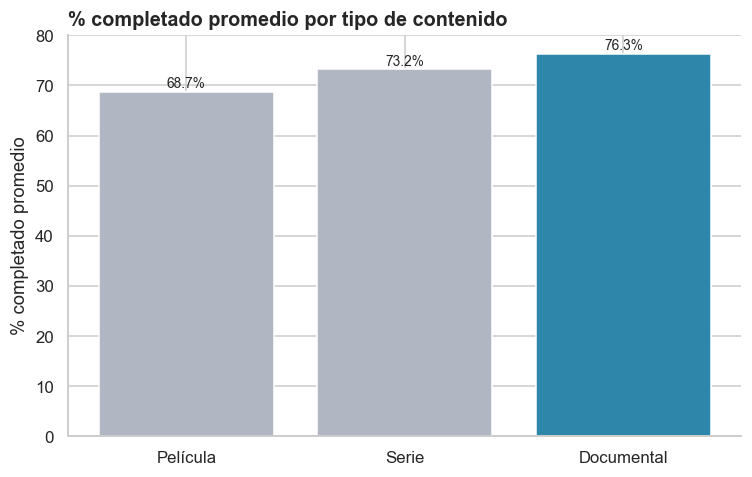

Minutos reproducidos promedio por sesión, según tipo de contenido:


tipo_contenido
Película      79.8
Serie         31.1
Documental    57.1
Name: minutos_reproducidos, dtype: float64

In [17]:
pct_tipo = rep_full.groupby('tipo_contenido')['porcentaje_completado'].mean().sort_values()
min_tipo = rep_full.groupby('tipo_contenido')['minutos_reproducidos'].mean().reindex(pct_tipo.index)

fig, ax = plt.subplots(figsize=(7, 4.5))
colores = [COLOR_ACENTO_POS if t == pct_tipo.idxmax() else COLOR_NEUTRO for t in pct_tipo.index]
bars = ax.bar(pct_tipo.index, pct_tipo.values, color=colores)
ax.set_title('% completado promedio por tipo de contenido', loc='left', fontweight='bold')
ax.set_ylabel('% completado promedio')
for b, v in zip(bars, pct_tipo.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.8, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Minutos reproducidos promedio por sesión, según tipo de contenido:")

min_tipo.round(1)

**Hallazgo:** los Documentales (76,3%) y Series (73,2%) se completan más que las Películas (68,7%). Al mismo tiempo, las películas tienen sesiones más largas en minutos (más duración por reproducción), mientras que las series se ven en episodios cortos pero con mayor tasa de avance relativo.

**¿Qué significa para StreamView?** El formato episódico (series/documentales) parece generar sesiones más "completas" — coherente con un consumo tipo maratón de episodios cortos. Las películas, al requerir un bloque de tiempo más largo y continuo, tienen más riesgo de quedar a medio ver. Esto es un insumo directo para el equipo de contenido (línea 4.3): no basta con mirar qué género gusta más, también importa el formato.

#### Contenidos más reproducidos

**¿Por qué este gráfico?** Ranking Top-N: barras horizontales ordenadas, la forma más legible para "leer" un ranking con etiquetas de texto largas (títulos).

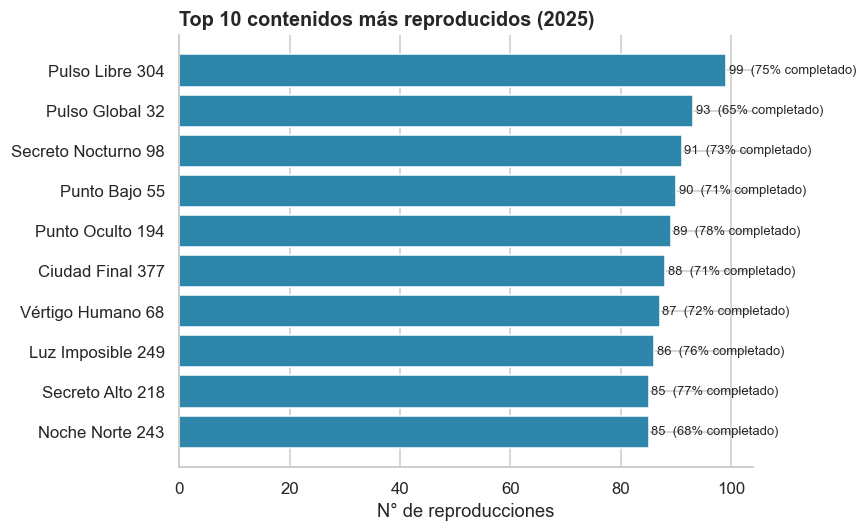

In [18]:
top10 = (
    rep_full.groupby('titulo')
    .agg(n_reproducciones=('reproduccion_id', 'count'), pct_completado_prom=('porcentaje_completado', 'mean'))
    .sort_values('n_reproducciones', ascending=False)
    .head(10)
    .sort_values('n_reproducciones')
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10.index, top10['n_reproducciones'], color=COLOR_ACENTO_POS)
ax.set_title('Top 10 contenidos más reproducidos (2025)', loc='left', fontweight='bold')
ax.set_xlabel('N° de reproducciones')
for i, (v, pct) in enumerate(zip(top10['n_reproducciones'], top10['pct_completado_prom'])):
    ax.text(v + 0.5, i, f'{v}  ({pct:.0f}% completado)', va='center', fontsize=8.5)
plt.tight_layout()
plt.show()

**Hallazgo:** la popularidad no siempre acompaña al % completado: 4 de los 10 títulos más vistos quedan bajo el promedio general de 71,5%, por ejemplo *Pulso Global 32* (93 reproducciones, 65,1%) y *Noche Norte 243* (85 reproducciones, 67,7%). Esto se retoma formalmente en 4.5.5 (popularidad vs. satisfacción).

**¿Qué significa para StreamView?** El volumen de reproducciones por sí solo no certifica que un contenido "funcione bien"; conviene mirarlo siempre junto al % completado antes de decidir renovar licencias o promocionar un título en la portada.

#### Recomendaciones

1. Priorizar mejoras de experiencia en **Móvil** (precarga, reproducción adaptativa, recuperación ante cortes): concentra el 76% del abandono temprano y el menor % completado.
2. Monitorear el **buffering** como KPI de calidad de servicio, no solo como métrica de infraestructura: está asociado a menor consumo efectivo.
3. Al evaluar el desempeño de un contenido, reportar siempre **reproducciones + % completado juntos**, no el volumen por sí solo.

### Preferencias de contenido — ✅ *Michel*

### Preferencias de contenido

#### 1. Géneros más consumidos según tiempo invertido

> **¿Qué queremos analizar?** Queremos identificar cuáles son los géneros principales que capturan la mayor parte del tiempo de atención de los usuarios.

> **¿Por qué elegimos este gráfico?** Un gráfico de barras horizontales permite comparar rápidamente el volumen total de minutos reproducidos por cada categoría, destacando a los líderes de manera intuitiva.

> **¿Qué hallazgo encontramos?** Se observa un género que lidera ampliamente en retención de atención (resaltado en azul), mientras que los demás mantienen niveles más uniformes.

> **¿Qué significa para la organización?** Este género es el pilar principal del *engagement* en la plataforma; los usuarios invierten gran parte de su tiempo en él.

> **¿Qué decisión o recomendación podemos proponer?** Priorizar la inversión del presupuesto de adquisición y producción de catálogo en este género líder, asegurando una rotación constante de estrenos para mantener a estos usuarios activos.

C:\Users\SEBASTIAN GONZALEZ\AppData\Local\Temp\ipykernel_3880\3763575801.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_generos, x='minutos_reproducidos', y='genero_principal', palette=colores_gen, ax=ax)


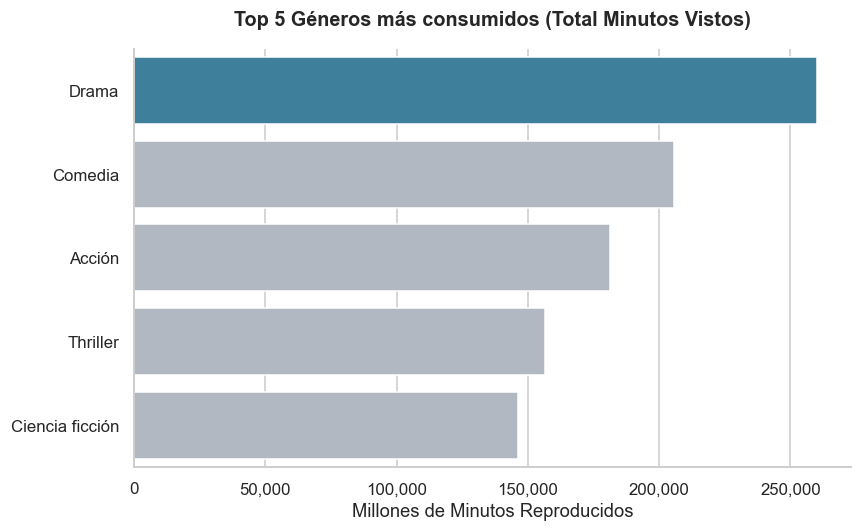

In [19]:
# Combinar reproducciones con la metadata de contenidos
rep_cont = pd.merge(reproducciones, contenidos, on='contenido_id', how='left')

# Calcular el total de minutos reproducidos por género principal
top_generos = rep_cont.groupby('genero_principal')['minutos_reproducidos'].sum().reset_index()
top_generos = top_generos.sort_values(by='minutos_reproducidos', ascending=False).head(5)

fig, ax = plt.subplots(figsize=(8, 5))

# Aplicar color de acento al primer elemento (el más visto) y neutro al resto
colores_gen = [COLOR_ACENTO_POS if i == 0 else COLOR_NEUTRO for i in range(len(top_generos))]

sns.barplot(data=top_generos, x='minutos_reproducidos', y='genero_principal', palette=colores_gen, ax=ax)
ax.set_title('Top 5 Géneros más consumidos (Total Minutos Vistos)', pad=15)
ax.set_xlabel('Millones de Minutos Reproducidos')
ax.set_ylabel('')

# Formatear el eje X para mayor legibilidad
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.tight_layout()
plt.show()

#### 2. Preferencia de formato (Tipo de contenido) por Segmento de Edad

> **¿Qué queremos analizar?** Cómo varía el consumo de películas, series y documentales dependiendo del grupo etario del usuario.

> **¿Por qué elegimos este gráfico?** Un gráfico de barras agrupadas facilita la comparación directa del volumen de reproducciones de distintos formatos dentro de cada cohorte generacional.

> **¿Qué hallazgo encontramos?** Existe una clara segmentación en la forma de consumir contenido; los distintos grupos de edad tienen proporciones diferentes en la elección de Series frente a Películas.

> **¿Qué significa para la organización?** El catálogo no es "talla única". Los usuarios más jóvenes pueden buscar maratones de series, mientras que otros segmentos podrían inclinarse por formatos más autoconclusivos.

> **¿Qué decisión o recomendación podemos proponer?** Personalizar la interfaz de inicio (Home) al momento del registro del usuario (Onboarding) destacando el formato preferido de su segmento de edad, antes de que el algoritmo recolecte suficientes datos individuales.

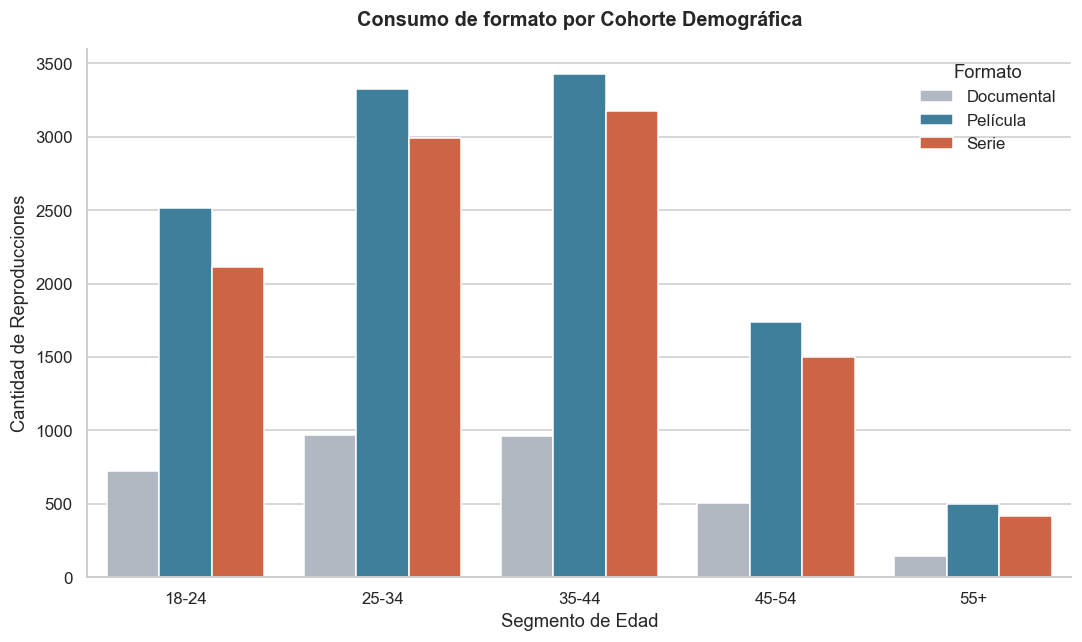

In [20]:
# Cruzar datos con usuarios para obtener el segmento de edad
rep_cont_usu = pd.merge(rep_cont, usuarios[['usuario_id', 'segmento_edad']], on='usuario_id', how='left')

# Contar reproducciones por segmento de edad y tipo de contenido
pref_edad = rep_cont_usu.groupby(['segmento_edad', 'tipo_contenido'])['reproduccion_id'].count().reset_index()
pref_edad.rename(columns={'reproduccion_id': 'cantidad_reproducciones'}, inplace=True)

# Ordenar lógicamente los segmentos de edad (asumiendo formato '18-24', '25-34', etc.)
orden_edades = sorted(pref_edad['segmento_edad'].unique())

fig, ax = plt.subplots(figsize=(10, 6))

# Usar paleta del equipo para diferenciar los tipos de contenido
paleta_tipos = [COLOR_NEUTRO, COLOR_ACENTO_POS, COLOR_ACENTO] 

sns.barplot(
    data=pref_edad, 
    x='segmento_edad', 
    y='cantidad_reproducciones', 
    hue='tipo_contenido', 
    order=orden_edades,
    palette=paleta_tipos, 
    ax=ax
)

ax.set_title('Consumo de formato por Cohorte Demográfica', pad=15)
ax.set_xlabel('Segmento de Edad')
ax.set_ylabel('Cantidad de Reproducciones')
ax.legend(title='Formato', frameon=False)

plt.tight_layout()
plt.show()

#### 3. Satisfacción del usuario: Géneros mejor calificados

> **¿Qué queremos analizar?** Cuáles son los géneros que, independientemente de su popularidad, generan la mayor satisfacción (mejores calificaciones) entre los usuarios que los ven.

> **¿Por qué elegimos este gráfico?** Un gráfico de barras horizontales permite mostrar la calificación promedio y ordenarla fácilmente, enfocándonos en la calidad percibida.

> **¿Qué hallazgo encontramos?** Los géneros con mejor puntuación (destacado en azul) no siempre coinciden con los géneros más reproducidos masivamente.

> **¿Qué significa para la organización?** Hay nichos de contenido de alta calidad que fidelizan enormemente a los usuarios que los consumen, generando "embajadores" de marca.

> **¿Qué decisión o recomendación podemos proponer?** Utilizar estos contenidos altamente valorados en estrategias de retención (ej. campañas de email marketing o notificaciones push) para usuarios con riesgo de *churn*, ya que tienen altas probabilidades de generar una experiencia positiva.

C:\Users\SEBASTIAN GONZALEZ\AppData\Local\Temp\ipykernel_3880\4012409720.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


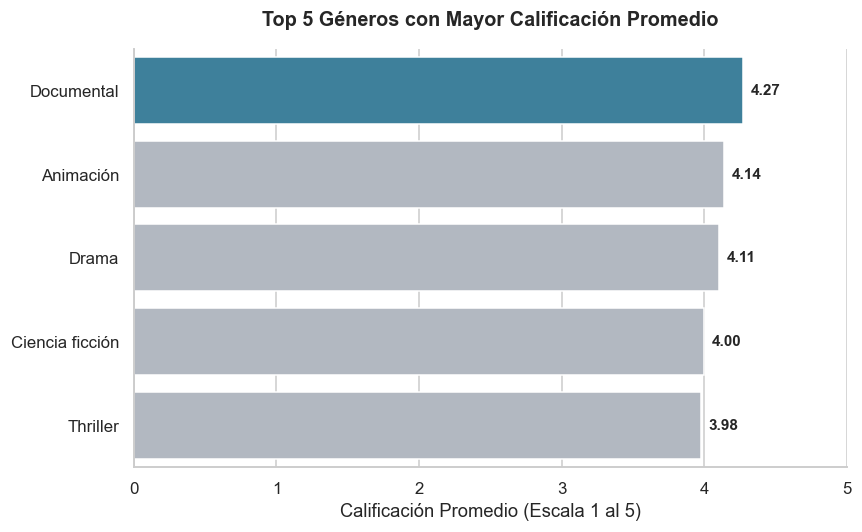

In [21]:
# Combinar calificaciones con contenidos
calif_cont = pd.merge(calificaciones, contenidos, on='contenido_id', how='left')

# Calcular promedio de calificación y volumen de reseñas por género
calif_gen = calif_cont.groupby('genero_principal').agg(
    promedio_calificacion=('puntuacion_1_5', 'mean'),
    volumen_calificaciones=('puntuacion_1_5', 'count')
).reset_index()

# Filtrar para evitar sesgos estadísticos (solo géneros con > 30 calificaciones)
calif_gen_robusto = calif_gen[calif_gen['volumen_calificaciones'] > 30]
top_calificados = calif_gen_robusto.sort_values(by='promedio_calificacion', ascending=False).head(5)

fig, ax = plt.subplots(figsize=(8, 5))

# Destacar el más valorado
colores_calif = [COLOR_ACENTO_POS if i == 0 else COLOR_NEUTRO for i in range(len(top_calificados))]

sns.barplot(
    data=top_calificados, 
    x='promedio_calificacion', 
    y='genero_principal', 
    palette=colores_calif, 
    ax=ax
)

ax.set_title('Top 5 Géneros con Mayor Calificación Promedio', pad=15)
ax.set_xlabel('Calificación Promedio (Escala 1 al 5)')
ax.set_ylabel('')

# Fijar límite del eje X de 0 a 5 por ser la escala natural
ax.set_xlim(0, 5) 

# Agregar etiquetas de valor en las barras
for p in ax.patches:
    ancho = p.get_width()
    ax.annotate(f'{ancho:.2f}', 
                (ancho, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), 
                textcoords='offset points',
                fontsize=10,
                fontweight='bold')

plt.tight_layout()
plt.show()

### Experiencia técnica por dispositivo — ✅ *Matias*


**Tablas principales:** `reproducciones`, `dispositivos`, `usuarios`, `suscripciones`

**¿Qué queremos analizar?**
Dónde falla la experiencia técnica de reproducción (buffering) según tipo de dispositivo, sistema operativo, versión de la app, calidad de video y país, y cuánto consumo le cuesta eso a StreamView..

**Hilo de la sección:** el buffering cuesta consumo → se concentra en móviles y tablets → dentro de ellos, en Android con app 6.8–6.9 → ese grupo pequeño genera una parte desproporcionada de los abandonos → foco secundario en Perú/Ecuador y en el 4K → límite: no explica las cancelaciones.

#### Preparación de datos

In [ ]:


# Tabla integrada a nivel reproducción: sesión + dispositivo (SO y versión de app) + país + plan/estado.
# No modificamos 'reproducciones' ni 'dispositivos' originales porque las usan otras secciones.
rep_tec = (
    reproducciones
    .merge(dispositivos[['dispositivo_id', 'sistema_operativo', 'version_app']]
               # la versión es una etiqueta, no un número: 7 -> '7.0'
               .assign(version_app=lambda d: d['version_app'].map('{:.1f}'.format)),
           on='dispositivo_id', how='left', validate='many_to_one')
    .merge(usuarios[['usuario_id', 'pais']], on='usuario_id', how='left', validate='many_to_one')
    .merge(suscripciones[['usuario_id', 'plan', 'estado']], on='usuario_id', how='left', validate='many_to_one')
)

ORDEN_VERSION = ['6.8', '6.9', '7.0', '7.1', '7.2']
FIJO, PORTATIL = 'Fijo (TV/PC/Consola)', 'Portátil (Móvil/Tablet)'
SEG_FIJO, SEG_PORT, SEG_ANDROID = 'Dispositivos fijos', 'Otros portátiles', 'Android con app 6.8–6.9'
SEGMENTOS = [SEG_FIJO, SEG_PORT, SEG_ANDROID]
UMBRAL_BUFFERING = 15  # segundos; se justifica en el primer gráfico

rep_tec['abandono'] = (rep_tec['abandono_temprano'] == 'Sí').astype(int)
rep_tec['buffering_alto'] = (rep_tec['buffering_segundos'] > UMBRAL_BUFFERING).astype(int)
rep_tec['portatil'] = rep_tec['tipo_dispositivo'].isin(['Móvil', 'Tablet'])
rep_tec['familia'] = np.where(rep_tec['portatil'], PORTATIL, FIJO)
rep_tec['app_antigua'] = rep_tec['version_app'].isin(['6.8', '6.9'])
rep_tec['segmento_tecnico'] = np.select(
    [rep_tec['sistema_operativo'].eq('Android') & rep_tec['app_antigua'], rep_tec['portatil']],
    [SEG_ANDROID, SEG_PORT], default=SEG_FIJO)

print(f"Reproducciones integradas: {len(rep_tec):,} (sin dispositivo encontrado: {rep_tec['sistema_operativo'].isna().sum()})")
print(f"Buffering promedio global: {rep_tec['buffering_segundos'].mean():.1f} s")
for familia, grupo in rep_tec.groupby('familia'):
    print(f"  {familia:<24} buffering {grupo['buffering_segundos'].mean():.1f} s | "
          f"sesiones con buffering >15 s: {grupo['buffering_alto'].mean() * 100:.1f}% | "
          f"% completado: {grupo['porcentaje_completado'].mean():.1f}%")

Reproducciones integradas: 25,000 (sin dispositivo encontrado: 0)
Buffering promedio global: 8.3 s
  Fijo (TV/PC/Consola)     buffering 5.8 s | sesiones con buffering >15 s: 1.7% | % completado: 76.8%
  Portátil (Móvil/Tablet)  buffering 11.5 s | sesiones con buffering >15 s: 24.3% | % completado: 64.6%


#### ¿Cuánto consumo cuesta el buffering?

**¿Por qué este gráfico?** Barras por tramos ordenados de buffering: la tendencia se lee de izquierda a derecha y los largos se comparan desde una base cero. Usamos dos paneles lado a lado en vez de un doble eje Y. Naranja = tramos de buffering alto (>15 s); gris = contexto.

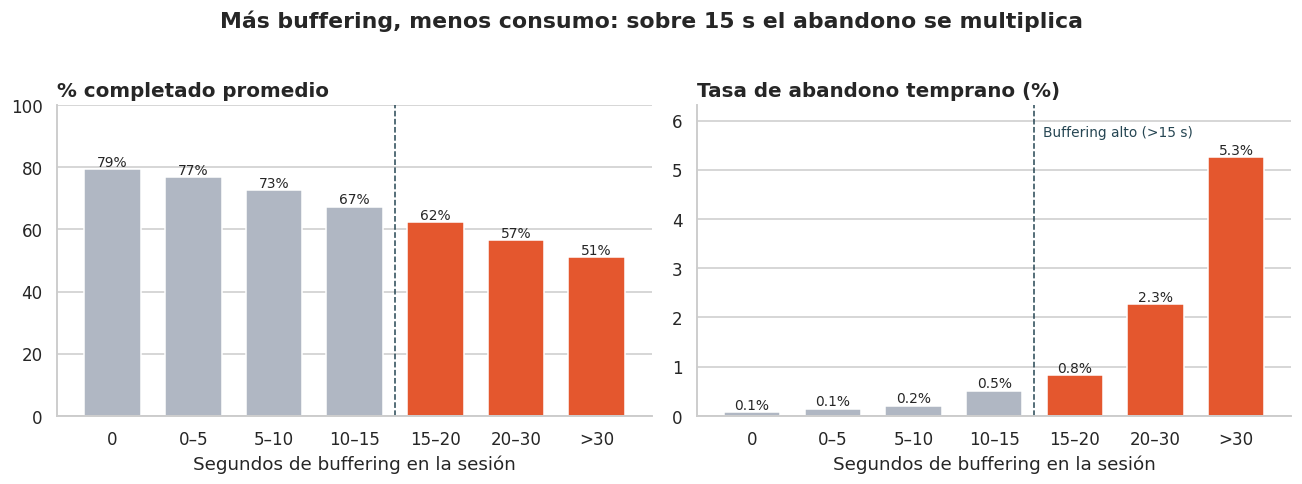

Cada segundo extra de buffering resta ≈ 0.98 puntos de % completado


,reproducciones,pct_completado,pct_abandono
tramo_buffering,,,
0,1259,79.46,0.08
0–5,6727,76.72,0.15
5–10,9083,72.58,0.21
10–15,5051,67.36,0.51
15–20,1820,62.32,0.82
20–30,927,56.59,2.27
>30,133,51.16,5.26


In [ ]:
tramos = ['0', '0–5', '5–10', '10–15', '15–20', '20–30', '>30']
rep_tec['tramo_buffering'] = pd.cut(rep_tec['buffering_segundos'], [-0.1, 0, 5, 10, 15, 20, 30, np.inf], labels=tramos)
buf_tramo = rep_tec.groupby('tramo_buffering', observed=True).agg(
    reproducciones=('reproduccion_id', 'count'),
    pct_completado=('porcentaje_completado', 'mean'),
    pct_abandono=('abandono', lambda s: s.mean() * 100))
pendiente = np.polyfit(rep_tec['buffering_segundos'], rep_tec['porcentaje_completado'], 1)[0]

colores = [COLOR_ACENTO if t in ['15–20', '20–30', '>30'] else COLOR_NEUTRO for t in buf_tramo.index]
pos_umbral = list(buf_tramo.index).index('15–20') - 0.5  # línea entre los tramos 10–15 y 15–20
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for ax, col, titulo, dec in [(axes[0], 'pct_completado', '% completado promedio', 0),
                             (axes[1], 'pct_abandono', 'Tasa de abandono temprano (%)', 1)]:
    bars = ax.bar(buf_tramo.index.astype(str), buf_tramo[col], color=colores, width=0.7)
    for b, v in zip(bars, buf_tramo[col]):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.{dec}f}%', ha='center', va='bottom', fontsize=9)
    ax.axvline(pos_umbral, color=COLOR_LINEA, linestyle='--', linewidth=1)
    ax.set_title(titulo, loc='left', fontweight='bold')
    ax.set_xlabel('Segundos de buffering en la sesión')
    ax.grid(axis='x', visible=False)
axes[0].set_ylim(0, 100)
axes[1].set_ylim(0, buf_tramo['pct_abandono'].max() * 1.2)
axes[1].text(pos_umbral + 0.1, buf_tramo['pct_abandono'].max() * 1.08, 'Buffering alto (>15 s)', color=COLOR_LINEA, fontsize=9)
fig.suptitle('Más buffering, menos consumo: sobre 15 s el abandono se multiplica', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Cada segundo extra de buffering resta ≈ {abs(pendiente):.2f} puntos de % completado")
buf_tramo.round(2)

**Hallazgo:** el % completado cae de forma sostenida a medida que sube el buffering: de 79,5% en sesiones sin buffering a 51,2% sobre los 30 s (≈ −1 punto de % completado por cada segundo extra). El abandono temprano se mantiene en ≤0,2% bajo los 10 s y se dispara sobre los 15 s: 0,8% (15–20 s) → 2,3% (20–30 s) → 5,3% (>30 s).

**¿Qué significa para StreamView?** Dimensiona el hallazgo de Hernan (correlación ≈ −0,31): el buffering reduce directamente el consumo y sobre 15 s el daño se acelera. Por eso usamos **15 s como umbral de "buffering alto"** en el resto de la sección y lo proponemos como KPI técnico del dashboard.

#### Buffering por tipo de dispositivo

**¿Por qué este gráfico?** Barras horizontales ordenadas: los nombres se leen sin girar la cabeza y el ranking es evidente. Mismo criterio de color del equipo: naranja donde está el problema (portátiles), gris para el resto. Cada barra lleva su valor y el % de sesiones sobre 15 s, así no hay que leer el eje.

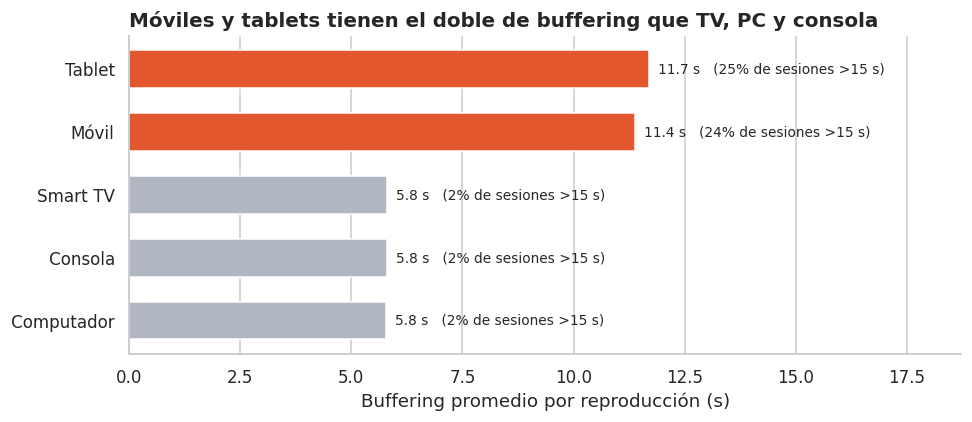

,reproducciones,buffering_prom,pct_buffering_alto,pct_completado
tipo_dispositivo,,,,
Computador,6290,5.79,1.62,73.48
Consola,876,5.80,2.17,76.67
Smart TV,7010,5.81,1.77,79.77
Móvil,7641,11.38,23.91,63.18
Tablet,3183,11.71,25.38,68.16


In [ ]:
buf_disp = rep_tec.groupby('tipo_dispositivo').agg(
    reproducciones=('reproduccion_id', 'count'),
    buffering_prom=('buffering_segundos', 'mean'),
    pct_buffering_alto=('buffering_alto', lambda s: s.mean() * 100),
    pct_completado=('porcentaje_completado', 'mean')).sort_values('buffering_prom')

fig, ax = plt.subplots(figsize=(9, 4))
colores = [COLOR_ACENTO if d in ['Móvil', 'Tablet'] else COLOR_NEUTRO for d in buf_disp.index]
ax.barh(buf_disp.index, buf_disp['buffering_prom'], color=colores, height=0.6)
for i, (v, alto) in enumerate(zip(buf_disp['buffering_prom'], buf_disp['pct_buffering_alto'])):
    ax.text(v + 0.2, i, f'{v:.1f} s   ({alto:.0f}% de sesiones >15 s)', va='center', fontsize=9)
ax.set_xlim(0, buf_disp['buffering_prom'].max() * 1.6)
ax.set_title('Móviles y tablets tienen el doble de buffering que TV, PC y consola', loc='left', fontweight='bold')
ax.set_xlabel('Buffering promedio por reproducción (s)')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

buf_disp.round(2)

**Hallazgo:** la experiencia técnica se divide en dos grupos, no en un gradiente: Móvil (11,4 s) y Tablet (11,7 s) tienen **el doble de buffering** que Smart TV, Computador y Consola (≈5,8 s), y 1 de cada 4 de sus sesiones supera los 15 s (vs ≈2% en los fijos). Es coherente con el gráfico de Hernan, donde Móvil tiene el menor % completado y el mayor abandono temprano.

**¿Qué significa para StreamView?** El problema técnico está en los portátiles, y Móvil es además el dispositivo con más reproducciones (7.641 de 25.000). Pero "móvil" es demasiado amplio para actuar: el siguiente gráfico muestra qué parte de los portátiles explica el problema.

#### El hallazgo clave: Android con app 6.8–6.9

**¿Por qué este gráfico?** Líneas sobre un eje ordenado (las versiones tienen orden) muestran el "salto" entre la 6.9 y la 7.0 mejor que las barras. Solo la serie foco (Android) va en naranja y más gruesa; Apple y los fijos quedan como referencia. Etiquetas directas en vez de leyenda. *(En la exploración también revisamos un mapa de calor sistema operativo × versión: el único punto caliente fue Android 6.8–6.9.)*

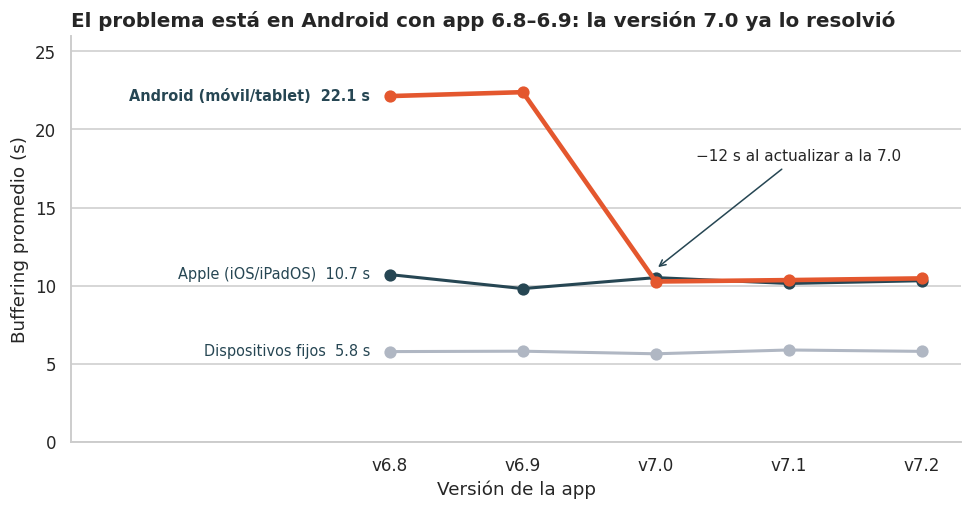

Android con app 6.8–6.9: 1,050 reproducciones en 103 dispositivos (103 usuarios)


,Android (móvil/tablet),Apple (iOS/iPadOS),Dispositivos fijos
version_app,,,
6.8,22.14,10.71,5.78
6.9,22.39,9.81,5.81
7.0,10.27,10.52,5.64
7.1,10.36,10.14,5.88
7.2,10.47,10.32,5.79


In [ ]:
ANDROID, APPLE = 'Android (móvil/tablet)', 'Apple (iOS/iPadOS)'
buf_version = pd.DataFrame({
    ANDROID: rep_tec[rep_tec['sistema_operativo'] == 'Android'].groupby('version_app')['buffering_segundos'].mean(),
    APPLE: rep_tec[rep_tec['sistema_operativo'].isin(['iOS', 'iPadOS'])].groupby('version_app')['buffering_segundos'].mean(),
    SEG_FIJO: rep_tec[~rep_tec['portatil']].groupby('version_app')['buffering_segundos'].mean(),
}).reindex(ORDEN_VERSION)

x = list(range(len(ORDEN_VERSION)))
estilos = {SEG_FIJO: (COLOR_NEUTRO, 2), APPLE: (COLOR_LINEA, 2), ANDROID: (COLOR_ACENTO, 3)}
fig, ax = plt.subplots(figsize=(9, 4.8))
for serie, (color, grosor) in estilos.items():
    ax.plot(x, buf_version[serie], color=color, linewidth=grosor, marker='o', markersize=7)
    # etiquetas a la izquierda: a la derecha Android y Apple se juntan
    ax.text(-0.15, buf_version[serie].iloc[0], f'{serie}  {buf_version[serie].iloc[0]:.1f} s',
            ha='right', va='center', fontsize=9.5, color=COLOR_LINEA,
            fontweight='bold' if serie == ANDROID else 'normal')
caida = buf_version.loc['6.9', ANDROID] - buf_version.loc['7.0', ANDROID]
ax.annotate(f'−{caida:.0f} s al actualizar a la 7.0', xy=(2, buf_version.loc['7.0', ANDROID] + 0.8),
            xytext=(2.3, 18), fontsize=10, arrowprops=dict(arrowstyle='->', color=COLOR_LINEA))
ax.set_xticks(x, [f'v{v}' for v in ORDEN_VERSION])
ax.set_xlim(-2.4, 4.3)
ax.set_ylim(0, 26)
ax.set_xlabel('Versión de la app')
ax.set_ylabel('Buffering promedio (s)')
ax.grid(axis='x', visible=False)
ax.set_title('El problema está en Android con app 6.8–6.9: la versión 7.0 ya lo resolvió', loc='left', fontweight='bold')
plt.tight_layout()
plt.show()

seg_android = rep_tec[rep_tec['segmento_tecnico'] == SEG_ANDROID]
print(f"{SEG_ANDROID}: {len(seg_android):,} reproducciones en {seg_android['dispositivo_id'].nunique()} dispositivos "
      f"({seg_android['usuario_id'].nunique()} usuarios)")
buf_version.round(2)

**Hallazgo:** en Android, las versiones 6.8 y 6.9 tienen **~22 s de buffering**; desde la 7.0 bajan a ~10 s, igual que Apple. En Apple y en los dispositivos fijos la versión de la app no cambia nada. El segmento afectado es acotado: 1.050 reproducciones en 103 dispositivos (103 usuarios).

**¿Qué significa para StreamView?** El problema no es "las apps antiguas" en general ni la red: es algo **específico del reproductor de Android anterior a la 7.0** (hipótesis a validar con el equipo técnico), y la versión 7.0 ya lo corrigió. Es decir, **la solución ya existe**; lo que falta es que esos usuarios actualicen.

#### Un grupo pequeño, un daño desproporcionado

**¿Por qué este gráfico?** Dos barras 100% apiladas, una sobre otra, comparan la **participación** de cada segmento técnico en el total: si un segmento se comportara "normal", su trozo tendría el mismo ancho en ambas barras. Gris claro = fijos, gris oscuro = otros portátiles, naranja = Android con app 6.8–6.9 (el foco).

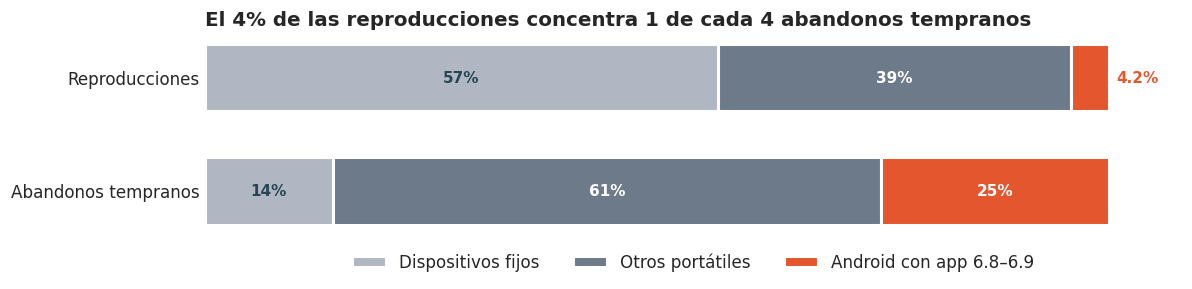

,reproducciones,buffering_prom,pct_completado,abandonos,pct_abandono
segmento_tecnico,,,,,
Dispositivos fijos,14176,5.80,76.79,14,0.10
Otros portátiles,9774,10.32,65.44,60,0.61
Android con app 6.8–6.9,1050,22.29,57.25,25,2.38


In [ ]:
metricas_seg = rep_tec.groupby('segmento_tecnico').agg(
    reproducciones=('reproduccion_id', 'count'),
    buffering_prom=('buffering_segundos', 'mean'),
    pct_completado=('porcentaje_completado', 'mean'),
    abandonos=('abandono', 'sum'),
    pct_abandono=('abandono', lambda s: s.mean() * 100)).loc[SEGMENTOS]

part_seg = pd.DataFrame({
    'Reproducciones': rep_tec['segmento_tecnico'].value_counts(normalize=True),
    'Abandonos tempranos': rep_tec.loc[rep_tec['abandono'] == 1, 'segmento_tecnico'].value_counts(normalize=True),
}).loc[SEGMENTOS].T * 100

COLOR_SEG = {SEG_FIJO: COLOR_NEUTRO, SEG_PORT: '#6C7A89', SEG_ANDROID: COLOR_ACENTO}
fig, ax = plt.subplots(figsize=(11, 2.8))
izquierda = np.zeros(len(part_seg))
for seg in SEGMENTOS:
    ax.barh(part_seg.index, part_seg[seg], left=izquierda, color=COLOR_SEG[seg],
            edgecolor='white', linewidth=2, height=0.6, label=seg)
    for fila, (v, inicio) in enumerate(zip(part_seg[seg], izquierda)):
        if v >= 8:
            ax.text(inicio + v / 2, fila, f'{v:.0f}%', ha='center', va='center', fontsize=10, fontweight='bold',
                    color=COLOR_LINEA if seg == SEG_FIJO else 'white')
        else:  # trozo muy chico (el último de la barra): etiqueta afuera, a la derecha
            ax.text(inicio + v + 0.8, fila, f'{v:.1f}%', ha='left', va='center', fontsize=10, fontweight='bold',
                    color=COLOR_ACENTO if seg == SEG_ANDROID else COLOR_LINEA)
    izquierda += part_seg[seg].values
ax.invert_yaxis()
ax.set_xlim(0, 108)
ax.set_xticks([])
ax.grid(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=False)
ax.set_title('El 4% de las reproducciones concentra 1 de cada 4 abandonos tempranos', loc='left', fontweight='bold')
plt.tight_layout()
plt.show()

metricas_seg.round(2)

**Hallazgo:** Android con app 6.8–6.9 es solo el **4,2% de las reproducciones**, pero genera el **25% de los abandonos tempranos** (25 de 99). Comparado con otros celulares y tablets tiene 2,2× el buffering (22,3 s vs 10,3 s), ve 8 puntos menos de cada contenido (57,3% vs 65,4% completado) y abandona 4× más (2,4% vs 0,6%).

**¿Qué significa para StreamView?** Es una acción de **alto impacto y bajo costo**: afecta a ~100 dispositivos y la versión corregida ya existe. *Estimación:* si ese grupo se comportara como el resto de los portátiles, su buffering bajaría ~12 s, su % completado subiría ~8 puntos y se evitarían ~19 de los 99 abandonos tempranos del año.

#### Foco geográfico: Perú y Ecuador

**¿Por qué este gráfico?** Gráfico de pesas (*dumbbell*): cada país es una fila con dos puntos, fijos (círculo vacío) y portátiles (círculo lleno). Se ve a la vez el nivel de cada país y la brecha entre familias, y separar por familia descarta que la diferencia se deba a que un país use más celulares. Naranja = países foco.

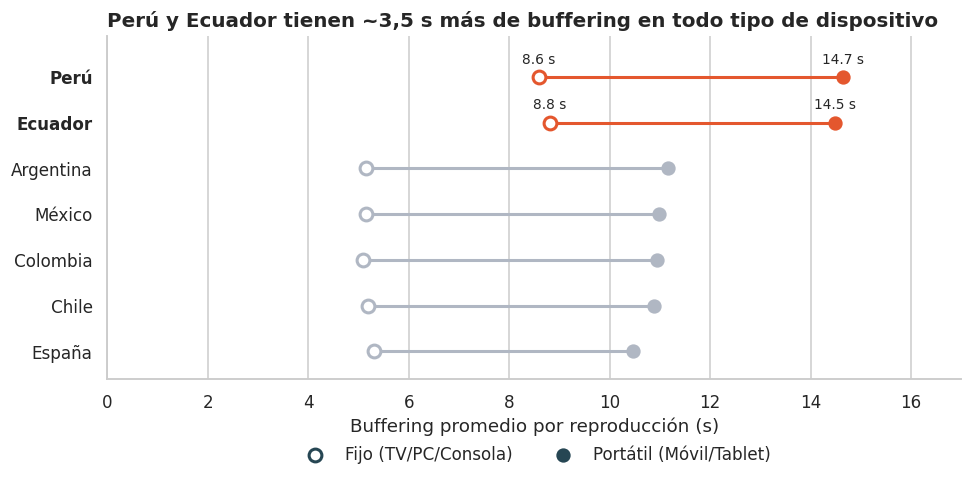

familia,Fijo (TV/PC/Consola),Portátil (Móvil/Tablet)
pais,,
España,5.30,10.46
Chile,5.18,10.88
Colombia,5.10,10.94
México,5.15,10.97
Argentina,5.16,11.16
Ecuador,8.81,14.48
Perú,8.59,14.65


In [ ]:
buf_pais = rep_tec.groupby(['pais', 'familia'])['buffering_segundos'].mean().unstack().sort_values(PORTATIL)
focos = ['Perú', 'Ecuador']

fig, ax = plt.subplots(figsize=(9, 4.6))
for i, pais in enumerate(buf_pais.index):
    color = COLOR_ACENTO if pais in focos else COLOR_NEUTRO
    fijo_s, port_s = buf_pais.loc[pais, FIJO], buf_pais.loc[pais, PORTATIL]
    ax.plot([fijo_s, port_s], [i, i], color=color, linewidth=2, zorder=1)
    ax.scatter(fijo_s, i, s=70, facecolor='white', edgecolor=color, linewidth=2, zorder=2)
    ax.scatter(port_s, i, s=70, color=color, zorder=2)
    if pais in focos:
        ax.text(fijo_s, i + 0.3, f'{fijo_s:.1f} s', ha='center', fontsize=9)
        ax.text(port_s, i + 0.3, f'{port_s:.1f} s', ha='center', fontsize=9)
ax.set_yticks(range(len(buf_pais)), buf_pais.index)
for etiqueta in ax.get_yticklabels():
    if etiqueta.get_text() in focos:
        etiqueta.set_fontweight('bold')
ax.set_ylim(-0.6, len(buf_pais) - 0.1)
ax.set_xlim(0, 17)
ax.set_xlabel('Buffering promedio por reproducción (s)')
ax.grid(axis='y', visible=False)
ax.scatter([], [], s=70, facecolor='white', edgecolor=COLOR_LINEA, linewidth=2, label=FIJO)
ax.scatter([], [], s=70, color=COLOR_LINEA, label=PORTATIL)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
ax.set_title('Perú y Ecuador tienen ~3,5 s más de buffering en todo tipo de dispositivo', loc='left', fontweight='bold')
plt.tight_layout()
plt.show()

buf_pais.round(2)

**Hallazgo:** Perú y Ecuador tienen **~3,5 s más de buffering en ambas familias**: en fijos 8,6–8,8 s vs ~5,2 s en el resto de los países, y en portátiles 14,5–14,7 s vs ~10,9 s. Juntos suman el 17% de las reproducciones.

**¿Qué significa para StreamView?** Como el aumento aparece en todo tipo de dispositivo (no solo en la app móvil), apunta a un problema de **red o de distribución de contenido (CDN) en esos países**, no a la app. Es un foco distinto al de Android y requiere otra acción.

#### Complemento: calidad de video 4K en portátiles

La tabla de calidad de video de Hernan muestra que el 4K tiene algo más de buffering (9,0 s vs ~8,1 s). Aquí lo separamos por familia de dispositivo y vemos qué plan usa más 4K. Es un efecto secundario, por eso lo dejamos como tabla y no como gráfico.

In [ ]:
ORDEN_CALIDAD = ['SD', 'HD', 'Full HD', '4K']
buf_calidad = (rep_tec.groupby(['calidad_video', 'familia'])['buffering_segundos'].mean()
               .unstack().reindex(ORDEN_CALIDAD))
calidad_por_plan = (pd.crosstab(rep_tec['plan'], rep_tec['calidad_video'], normalize='index') * 100)[ORDEN_CALIDAD]

print('Buffering promedio (s) por calidad de video y familia:')
display(buf_calidad.round(2))
print('% de reproducciones de cada plan según calidad de video:')
calidad_por_plan.round(1)

Buffering promedio (s) por calidad de video y familia:


familia,Fijo (TV/PC/Consola),Portátil (Móvil/Tablet)
calidad_video,,
SD,5.40,11.33
HD,5.43,11.35
Full HD,5.35,11.22
4K,7.47,13.37


% de reproducciones de cada plan según calidad de video:


calidad_video,SD,HD,Full HD,4K
plan,,,,
Básico,14.1,52.6,29.2,4.0
Estándar,6.1,32.3,49.9,11.8
Premium,3.6,21.6,40.7,34.1


**Hallazgo:** SD, HD y Full HD tienen el mismo buffering; **el 4K suma ~2 s** en ambas familias y en portátiles llega a **13,4 s**. El plan Premium reproduce el 34% de su contenido en 4K (Básico: 4%).

**¿Qué significa para StreamView?** El 4K en una pantalla de celular aporta poco valor visual y sí agrega buffering, y lo sufren sobre todo **los clientes que más pagan**.

#### Lo que el dato NO dice: ¿la mala experiencia técnica explica las cancelaciones?

**¿Por qué este gráfico?** A la izquierda, los usuarios agrupados en cuartiles según su buffering promedio, con una línea en la tasa de cancelación promedio: si hubiera relación, las barras subirían de izquierda a derecha. A la derecha, los motivos declarados de cancelación, con "Problemas técnicos" destacado. Conecta esta sección con la de retención de Sebastián.

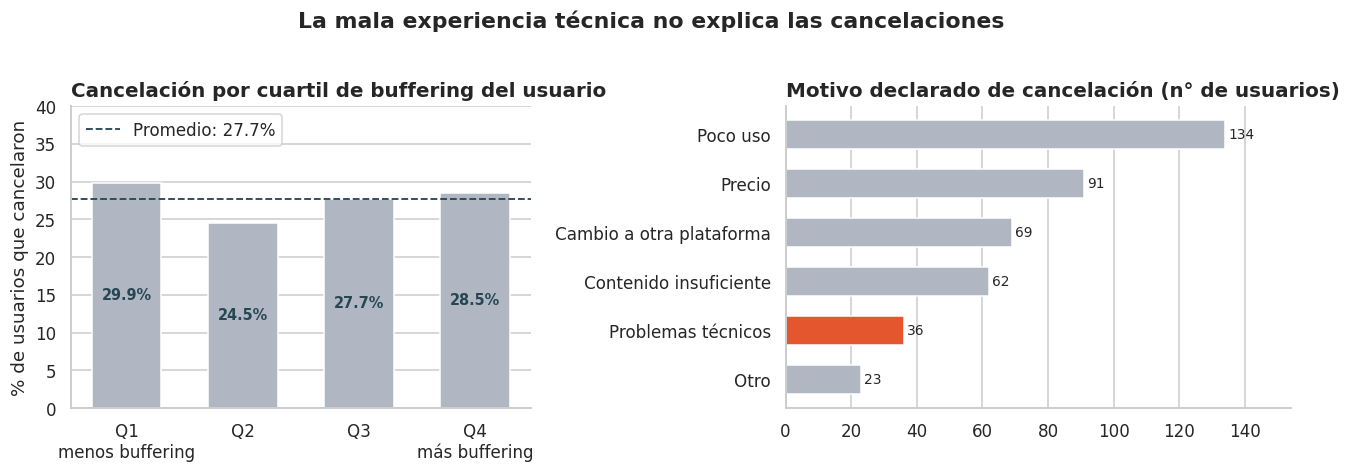

Cancelación por cuartil de buffering: entre 24.5% y 29.9% (promedio 27.7%)


In [ ]:
usuario_tec = (rep_tec.groupby('usuario_id')['buffering_segundos'].mean().rename('buffering_prom').reset_index()
               .merge(suscripciones[['usuario_id', 'estado']], on='usuario_id'))
usuario_tec['cancelo'] = usuario_tec['estado'].eq('Cancelada')
cuartiles = ['Q1\nmenos buffering', 'Q2', 'Q3', 'Q4\nmás buffering']
usuario_tec['cuartil_buffering'] = pd.qcut(usuario_tec['buffering_prom'], 4, labels=cuartiles)
churn_cuartil = usuario_tec.groupby('cuartil_buffering', observed=True)['cancelo'].mean() * 100
churn_total = usuario_tec['cancelo'].mean() * 100
motivos = suscripciones['motivo_cancelacion'].value_counts().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={'width_ratios': [1, 1.1]})
bars = axes[0].bar(churn_cuartil.index.astype(str), churn_cuartil.values, color=COLOR_NEUTRO, width=0.6)
for b, v in zip(bars, churn_cuartil.values):
    axes[0].text(b.get_x() + b.get_width() / 2, v / 2, f'{v:.1f}%', ha='center', va='center', fontsize=9.5,
                 fontweight='bold', color=COLOR_LINEA)
axes[0].axhline(churn_total, color=COLOR_LINEA, linestyle='--', linewidth=1.2, label=f'Promedio: {churn_total:.1f}%')
axes[0].set_ylim(0, 40)
axes[0].set_ylabel('% de usuarios que cancelaron')
axes[0].set_title('Cancelación por cuartil de buffering del usuario', loc='left', fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(axis='x', visible=False)

colores = [COLOR_ACENTO if m == 'Problemas técnicos' else COLOR_NEUTRO for m in motivos.index]
axes[1].barh(motivos.index, motivos.values, color=colores, height=0.6)
for i, v in enumerate(motivos.values):
    axes[1].text(v + 1, i, str(v), va='center', fontsize=9)
axes[1].set_xlim(0, motivos.max() * 1.15)
axes[1].set_title('Motivo declarado de cancelación (n° de usuarios)', loc='left', fontweight='bold')
axes[1].grid(axis='y', visible=False)

fig.suptitle('La mala experiencia técnica no explica las cancelaciones', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Cancelación por cuartil de buffering: entre {churn_cuartil.min():.1f}% y {churn_cuartil.max():.1f}% "
      f"(promedio {churn_total:.1f}%)")

### 4.5 Relación entre consumo, interacciones y calificaciones — ✅ *Hernan*

**Responsable:** [Hernan]
**Pregunta del README:** *Relación entre consumo, interacciones y calificaciones.*
**Tablas principales:** `reproducciones`, `interacciones`, `calificaciones`

**¿Qué queremos analizar?**
Si consumir más (reproducciones, minutos, % completado) se relaciona con interactuar más (me gusta, compartir, agregar a lista) y con calificar mejor. La hipótesis de negocio habitual es *"quien más ve, más le gusta, mejor califica y más recomienda"* — la ponemos a prueba con los datos.

### Preparación: agregados a nivel usuario, contenido y par usuario–contenido

In [22]:
# --- Nivel usuario ---
cons_usr = reproducciones.groupby('usuario_id').agg(
    n_reproducciones=('reproduccion_id', 'count'),
    minutos_totales=('minutos_reproducidos', 'sum'),
    pct_completado_prom=('porcentaje_completado', 'mean')
).reset_index()

inter_usr = interacciones.groupby('usuario_id').agg(n_interacciones=('interaccion_id', 'count')).reset_index()
me_gusta_usr = interacciones[interacciones['tipo_interaccion'] == 'Me gusta'].groupby('usuario_id').size().rename('n_me_gusta')

calif_usr = calificaciones.groupby('usuario_id').agg(
    n_calificaciones=('calificacion_id', 'count'),
    puntuacion_prom=('puntuacion_1_5', 'mean')
).reset_index()
recomend_usr = calificaciones.groupby('usuario_id')['recomendaria'].apply(lambda x: (x == 'Sí').mean()).rename('tasa_recomendaria')

usuario_360 = (
    cons_usr.merge(inter_usr, on='usuario_id', how='left')
            .merge(calif_usr, on='usuario_id', how='left')
            .merge(me_gusta_usr, on='usuario_id', how='left')
            .merge(recomend_usr, on='usuario_id', how='left')
)
# Conteos sin registros = 0. Los PROMEDIOS de quien nunca calificó quedan vacíos (NaN):
# rellenarlos con 0 inventa una correlación entre N° de calificaciones y puntuación.
conteos_usr = [c for c in usuario_360.columns if c.startswith('n_')]
usuario_360[conteos_usr] = usuario_360[conteos_usr].fillna(0)

# --- Nivel contenido ---
cons_cont = reproducciones.groupby('contenido_id').agg(
    n_reproducciones=('reproduccion_id', 'count'),
    minutos_totales=('minutos_reproducidos', 'sum'),
    pct_completado_prom=('porcentaje_completado', 'mean')
).reset_index()
inter_cont = interacciones.groupby('contenido_id').agg(n_interacciones=('interaccion_id', 'count')).reset_index()
calif_cont = calificaciones.groupby('contenido_id').agg(
    n_calificaciones=('calificacion_id', 'count'),
    puntuacion_prom=('puntuacion_1_5', 'mean')
).reset_index()

contenido_360 = (
    cons_cont.merge(inter_cont, on='contenido_id', how='left')
             .merge(calif_cont, on='contenido_id', how='left')
)
conteos_cont = [c for c in contenido_360.columns if c.startswith('n_')]
contenido_360[conteos_cont] = contenido_360[conteos_cont].fillna(0)

# --- Nivel par usuario-contenido: cruzamos cada calificación con el % completado
#     que ese mismo usuario tuvo en ese mismo contenido ---
rep_pair = reproducciones.groupby(['usuario_id', 'contenido_id'])['porcentaje_completado'].mean().reset_index()
calif_pair = calificaciones.merge(rep_pair, on=['usuario_id', 'contenido_id'], how='inner')

print(f"Usuarios con vista 360°: {len(usuario_360):,}")
print(f"  de ellos sin calificaciones (quedan fuera de las correlaciones de puntuación): {usuario_360['puntuacion_prom'].isna().sum():,}")
print(f"Contenidos con vista 360°: {len(contenido_360):,}")
print(f"Pares calificación-reproducción cruzados: {len(calif_pair):,} de {len(calificaciones):,} calificaciones")

Usuarios con vista 360°: 1,500
  de ellos sin calificaciones (quedan fuera de las correlaciones de puntuación): 238
Contenidos con vista 360°: 420
Pares calificación-reproducción cruzados: 3,119 de 3,119 calificaciones


#### % Completado vs. Puntuación entregada (el mismo usuario, el mismo contenido)

**¿Por qué este gráfico?** Este es el cruce más directo posible: para cada calificación, miramos cuánto completó ese usuario ese contenido específico. Usamos barras porque `puntuacion_1_5` es una escala discreta de 5 categorías ordinales.

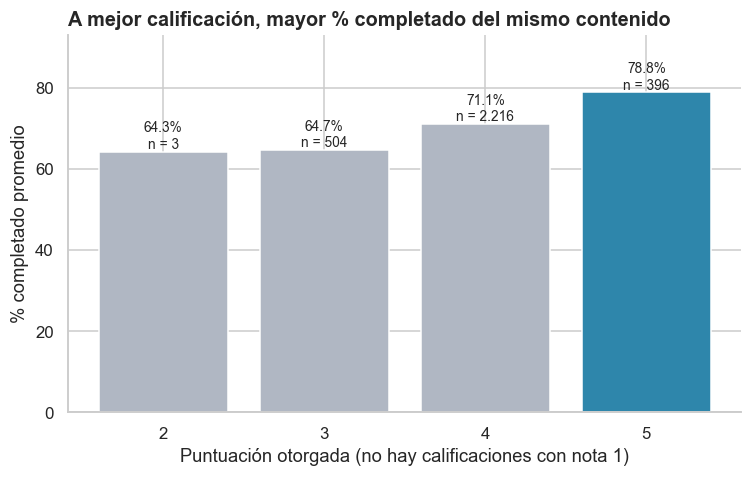

Correlación puntuación vs. % completado (a nivel par usuario-contenido): 0.20


In [23]:
por_puntuacion = calif_pair.groupby('puntuacion_1_5').agg(
    pct=('porcentaje_completado', 'mean'),
    n=('calificacion_id', 'count')
)

fig, ax = plt.subplots(figsize=(7, 4.5))
colores = [COLOR_ACENTO_POS if p == por_puntuacion.index.max() else COLOR_NEUTRO for p in por_puntuacion.index]
bars = ax.bar(por_puntuacion.index.astype(str), por_puntuacion['pct'], color=colores)
ax.set_title('A mejor calificación, mayor % completado del mismo contenido', loc='left', fontweight='bold')
ax.set_xlabel('Puntuación otorgada (no hay calificaciones con nota 1)')
ax.set_ylabel('% completado promedio')
ax.set_ylim(0, por_puntuacion['pct'].max() * 1.18)
for b, (v, n) in zip(bars, por_puntuacion[['pct', 'n']].itertuples(index=False)):
    ax.text(b.get_x() + b.get_width()/2, v + 0.8, f'{v:.1f}%\nn = {n:,}'.replace(',', '.'), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

corr_pair = calif_pair[['puntuacion_1_5', 'porcentaje_completado']].corr().iloc[0, 1]
print(f"Correlación puntuación vs. % completado (a nivel par usuario-contenido): {corr_pair:.2f}")

**Hallazgo:** esta es la relación más clara de la sección. El % completado sube con la puntuación: de 64,7% con nota 3 (504 calificaciones) a 71,1% con nota 4 (2.216) y 78,8% con nota 5 (396). La nota 2 tiene solo 3 casos y no se usa para concluir; no hay calificaciones con nota 1. La correlación es débil (0,20), pero el patrón es monotónico.

**¿Qué significa para StreamView?** El **comportamiento real de visionado (% completado) es un buen termómetro de satisfacción**: quienes terminan el contenido, en promedio, lo valoran mejor. Esto abre una oportunidad de negocio: usar el % completado como *proxy* de satisfacción en tiempo real, sin depender de que el usuario se tome el tiempo de calificar (solo el 12,7% de las reproducciones tiene una calificación asociada).

#### ¿El volumen de consumo se relaciona con interactuar y calificar mejor? (nivel usuario y nivel contenido)

**¿Por qué este gráfico?** Un mapa de calor de correlaciones permite ver de un vistazo si existe o no relación lineal entre muchas variables a la vez, sin tener que armar un gráfico de dispersión por cada par.

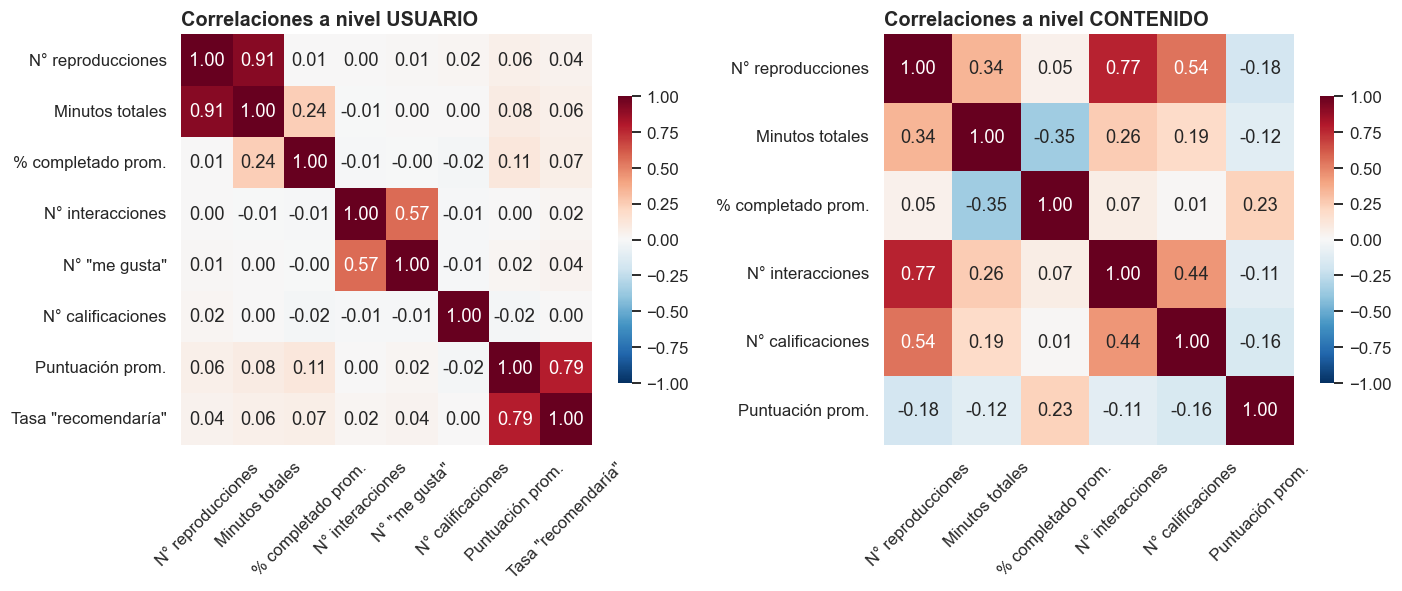

In [24]:
cols_usr = ['n_reproducciones', 'minutos_totales', 'pct_completado_prom',
            'n_interacciones', 'n_me_gusta', 'n_calificaciones', 'puntuacion_prom', 'tasa_recomendaria']
cols_cont = ['n_reproducciones', 'minutos_totales', 'pct_completado_prom',
             'n_interacciones', 'n_calificaciones', 'puntuacion_prom']

etiquetas = {
    'n_reproducciones': 'N° reproducciones', 'minutos_totales': 'Minutos totales',
    'pct_completado_prom': '% completado prom.', 'n_interacciones': 'N° interacciones',
    'n_me_gusta': 'N° "me gusta"', 'n_calificaciones': 'N° calificaciones',
    'puntuacion_prom': 'Puntuación prom.', 'tasa_recomendaria': 'Tasa "recomendaría"'
}

corr_usr = usuario_360[cols_usr].corr().rename(columns=etiquetas, index=etiquetas)
corr_cont = contenido_360[cols_cont].corr().rename(columns=etiquetas, index=etiquetas)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
sns.heatmap(corr_usr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': .7}, ax=axes[0])
axes[0].set_title('Correlaciones a nivel USUARIO', loc='left', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(corr_cont, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': .7}, ax=axes[1])
axes[1].set_title('Correlaciones a nivel CONTENIDO', loc='left', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Hallazgo:** a **nivel usuario**, cuánto reproduce o cuántos minutos acumula un usuario casi no se relaciona con cuánto interactúa (≈0,00) ni con cómo califica (0,06 a 0,08): **ver mucho no implica interactuar más ni calificar mejor.** Tampoco califican más alto quienes califican más seguido (−0,02). La única señal, débil, es que quien completa más lo que ve califica algo mejor (0,11), coherente con 4.5.2. *Nota: los 238 usuarios que nunca calificaron no entran en las correlaciones de puntuación y recomendación; sus promedios no se rellenan con 0.*

A **nivel contenido** el patrón es distinto: más reproducciones traen más interacciones (0,77), algo esperable por exposición, pero la relación con la puntuación es débil y **negativa** (−0,18): los contenidos más vistos no son necesariamente los mejor evaluados.

**¿Qué significa para StreamView?** El volumen de consumo (a nivel usuario) **no es un buen indicador de satisfacción o de propensión a recomendar**; son fenómenos relativamente independientes. Para retención y NPS, StreamView necesita mirar señales de calidad de la experiencia (como el % completado de 4.5.2) y no solo cuánto tiempo pasa el usuario en la app.

### ¿Reaccionar ("me gusta" / "no me gusta" / agregar a lista) se relaciona con calificar mejor ese mismo contenido?

**¿Por qué este gráfico?** Comparación de un promedio (puntuación) entre dos grupos (dejó vs. no dejó la interacción) → barras agrupadas, ideal para contrastes binarios simples.

C:\Users\SEBASTIAN GONZALEZ\AppData\Local\Temp\ipykernel_3880\3429970926.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  calif_flags[['dejo_me_gusta', 'agrego_lista']] = calif_flags[['dejo_me_gusta', 'agrego_lista']].fillna(False)


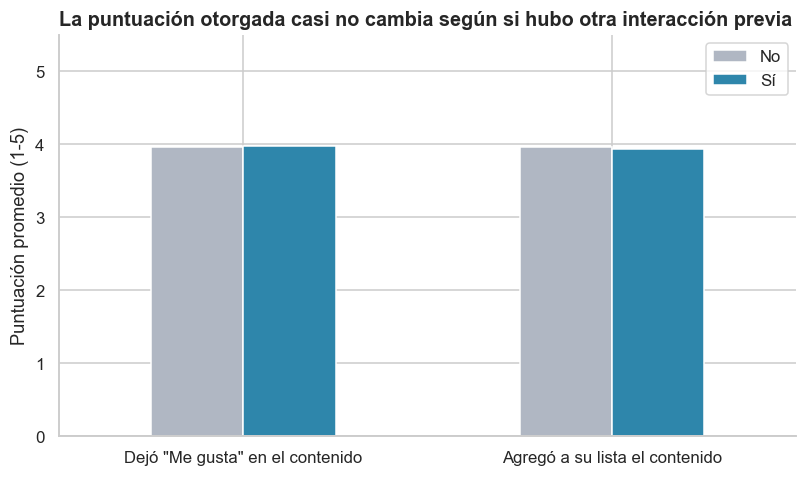

,"Dejó ""Me gusta"" en el contenido",Agregó a su lista el contenido
No,3.96,3.97
Sí,3.97,3.94


In [25]:
def flag_interaccion(tipo, nombre_col):
    pares = interacciones[interacciones['tipo_interaccion'] == tipo][['usuario_id', 'contenido_id']].drop_duplicates()
    pares[nombre_col] = True
    return pares

calif_flags = calif_pair.merge(flag_interaccion('Me gusta', 'dejo_me_gusta'), on=['usuario_id', 'contenido_id'], how='left')
calif_flags = calif_flags.merge(flag_interaccion('Agregar a mi lista', 'agrego_lista'), on=['usuario_id', 'contenido_id'], how='left')
calif_flags[['dejo_me_gusta', 'agrego_lista']] = calif_flags[['dejo_me_gusta', 'agrego_lista']].fillna(False)

resumen_flags = pd.DataFrame({
    'Dejó "Me gusta" en el contenido': calif_flags.groupby('dejo_me_gusta')['puntuacion_1_5'].mean(),
    'Agregó a su lista el contenido': calif_flags.groupby('agrego_lista')['puntuacion_1_5'].mean(),
})
resumen_flags.index = ['No', 'Sí']

fig, ax = plt.subplots(figsize=(7.5, 4.5))
resumen_flags.T.plot(kind='bar', ax=ax, color=[COLOR_NEUTRO, COLOR_ACENTO_POS], rot=0)
ax.set_title('La puntuación otorgada casi no cambia según si hubo otra interacción previa', loc='left', fontweight='bold')
ax.set_ylabel('Puntuación promedio (1-5)')
ax.set_ylim(0, 5.5)
ax.legend(title='')
plt.tight_layout()
plt.show()

resumen_flags.round(2)

**Hallazgo:** la puntuación promedio casi no varía según si el usuario dejó "Me gusta" (3,97 vs. 3,96) o agregó el contenido a su lista (3,94 vs. 3,97) en ese mismo título. Estas interacciones "declarativas" rápidas no distinguen bien entre quienes califican alto y bajo.

**¿Qué significa para StreamView?** Confirma el hallazgo de completado vs. puntuación entregada desde otro ángulo: las **interacciones de un clic** (me gusta, agregar a lista) son señales débiles de satisfacción real, mientras que el **comportamiento de consumo** (% completado) sí distingue claramente. Si el equipo de Producto necesita un indicador temprano de satisfacción, el consumo real es más confiable que los contadores de "me gusta".

#### Popularidad vs. satisfacción a nivel de contenido

**¿Por qué este gráfico?** Dispersión con tamaño de punto: permite ver simultáneamente 3 variables (reproducciones en X, puntuación en Y, volumen de calificaciones en el tamaño del punto) sin saturar el gráfico.

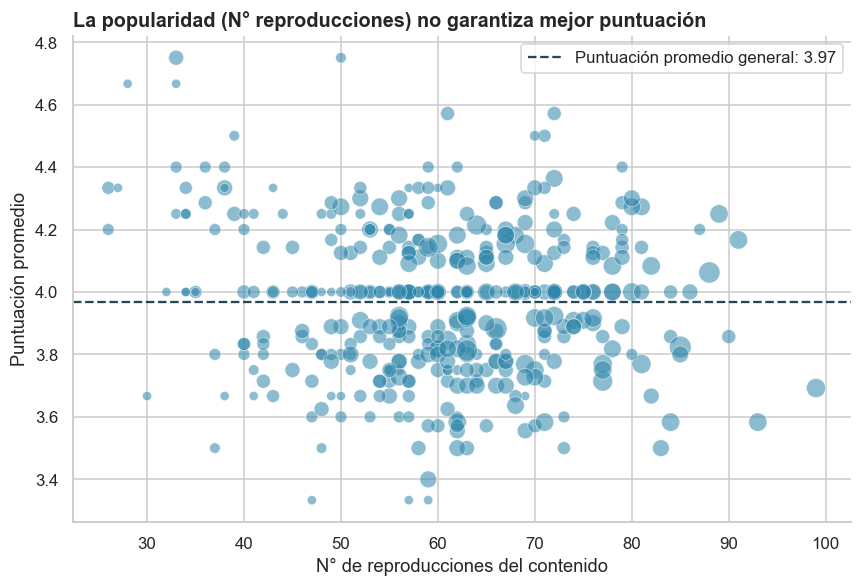

Contenidos con 3 o más calificaciones: 405 · correlación reproducciones vs. puntuación: -0.11


In [26]:
plot_df = contenido_360[contenido_360['n_calificaciones'] >= 3]

fig, ax = plt.subplots(figsize=(8, 5.5))
sc = ax.scatter(
    plot_df['n_reproducciones'], plot_df['puntuacion_prom'],
    s=plot_df['n_calificaciones'] * 12, alpha=0.55,
    color=COLOR_ACENTO_POS, edgecolor='white', linewidth=0.5
)
ax.set_title('La popularidad (N° reproducciones) no garantiza mejor puntuación', loc='left', fontweight='bold')
ax.set_xlabel('N° de reproducciones del contenido')
ax.set_ylabel('Puntuación promedio')
ax.axhline(plot_df['puntuacion_prom'].mean(), color=COLOR_LINEA, linestyle='--', linewidth=1.5,
           label=f'Puntuación promedio general: {plot_df["puntuacion_prom"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

corr_pop = plot_df['n_reproducciones'].corr(plot_df['puntuacion_prom'])
print(f"Contenidos con 3 o más calificaciones: {len(plot_df)} · correlación reproducciones vs. puntuación: {corr_pop:.2f}")

**Hallazgo:** el gráfico confirma visualmente la correlación negativa débil vista en el mapa de calor (−0,18; −0,11 entre los 405 contenidos con 3 o más calificaciones que muestra este gráfico): hay contenidos con muchas reproducciones cuya puntuación está bajo el promedio general, y contenidos con pocas reproducciones pero muy bien evaluados (posibles "joyas ocultas" del catálogo).

**¿Qué significa para StreamView?** Un ranking de "más vistos" no debería usarse como *proxy* de calidad percibida para decisiones editoriales (portada, recomendación, renovación de licencias). Conviene cruzar siempre popularidad con puntuación y % completado antes de decidir qué destacar.